In [212]:
%%capture
%pip install -r requirements.txt 

In [213]:
st_petersburg_incart_12lead_arrhythmia_database_path = r'data/china-12lead-ecg-challenge-database'
ptbxl_electrocardiography_database_path = r'data/ptbxl_electrocardiography_database'
ptb_diagnostic_ecg_database_path = r'data/ptb_diagnostic_ecg_database'
china_physiological_signal_challenge_in_2018_path = r'data/china_physiological_signal_challenge_2018'
china_12lead_ecg_challenge_database_path = r'data/china_12lead_ecg_challenge_database'
physionet_snomed_mappings_path = r'data/physionet_snomed_mappings'
physionet_challenge_models_path = r'datas/physionet_challenge_models'
georgia_12lead_ecg_challenge_database_path = r'data/georgia_12lead_ecg_challenge_database'
physionet_challenge_utility_script_path = r'notebooks/physionet_challenge_utility_script_patched_v2.py'

In [ ]:
# =========================
# Standard library imports
# =========================
import os
import sys
import types
import itertools
import re
from pathlib import Path

# =========================
# Third-party libraries
# =========================
import numpy as np
import pandas as pd
import shap

# Plotting
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ecg_plot

# ML / DL
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow import keras
from keras.utils import plot_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

import sklearn
from sklearn.linear_model import LinearRegression

# SciPy
from scipy import optimize

# =========================
# Project-specific paths
# =========================
physionet_delineation_path = r"...\delineation.py"
physionet_faithfulness_path = r"...\delineation.py"
physionet_bridge_path      = r"...\bridge.py"

sys.path.append(os.path.dirname(physionet_delineation_path))
sys.path.append(os.path.dirname(physionet_faithfulness_path))
sys.path.append(os.path.dirname(physionet_bridge_path))

# If defined elsewhere, ensure this path is on sys.path
physionet_challenge_utility_script_path = r"...\physionet_challenge_utility_script_patched_v2.py"
sys.path.append(os.path.dirname(physionet_challenge_utility_script_path))

# =========================
# Project-specific imports
# =========================
from delineation import (
    detect_r_peaks,
    delineate_heuristic,
    aggregate_attribution_by_intervals,
    lead_wave_table,
)
from faithfulness import insertion_deletion_auc
from bridge import (
    find_ecg_batch,
    to_batch_L_T,
    find_fs,
    make_keras_predict_fn,
    integrated_gradients_keras,
)

import physionet_challenge_utility_script_patched_v2 as pc

# =========================
# see-rnn compatibility shim
# =========================
see_rnn_repo_dir = "see-rnn"

if not os.path.exists(see_rnn_repo_dir):
    # If running in a notebook, this shell command will clone the repo.
    # In a pure .py script, replace with GitPython or manual clone.
    os.system("git clone https://github.com/OverLordGoldDragon/see-rnn.git")

# Add repo to path so we can import it
sys.path.insert(1, see_rnn_repo_dir)

# Try to provide the legacy import path that see-rnn expects for LossScaleOptimizer
try:
    # TF ≥ 2.4
    from tensorflow.keras.mixed_precision import LossScaleOptimizer
except Exception:
    try:
        # TF 2.3-era experimental path
        from tensorflow.keras.mixed_precision.experimental import LossScaleOptimizer  # type: ignore
    except Exception:
        LossScaleOptimizer = None  # fallback

if LossScaleOptimizer is not None:
    mod = types.ModuleType("tensorflow.python.keras.mixed_precision.experimental")

    class _LSO:  # acts like the old module object
        LossScaleOptimizer = LossScaleOptimizer

    mod.loss_scale_optimizer = _LSO
    sys.modules["tensorflow.python.keras.mixed_precision.experimental"] = mod

from see_rnn import get_gradients, get_outputs, features_0D, features_1D, features_2D

# =========================
# (Optional) Jupyter autoreload
# =========================
# %load_ext autoreload
# %autoreload 2


In [123]:
MainPath = os.path.join(os.path.expanduser("~"), "Documents", "cvd-early-detection-ecg-uhull")

if os.path.isdir(MainPath):
    os.chdir(MainPath)
else:
    raise FileNotFoundError(MainPath)


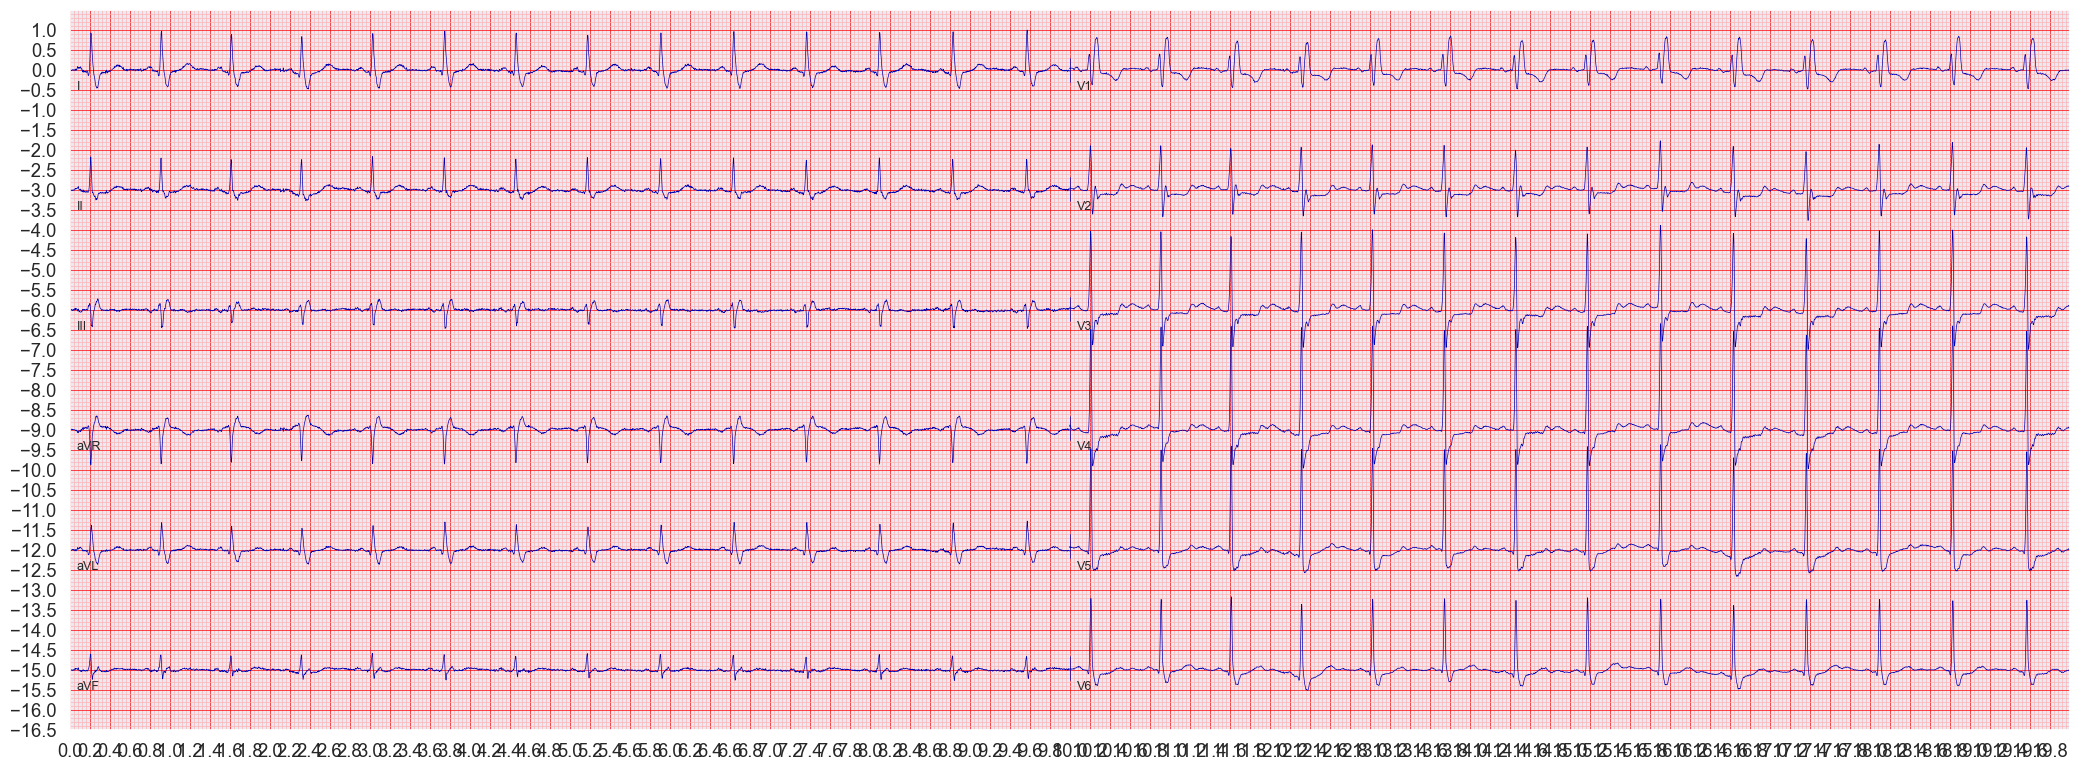

In [124]:
def plot_ecg(path):
    ecg_data = pc.load_challenge_data(path)
    ecg_plot.plot(ecg_data[0]/1000, sample_rate=500, title='')
    ecg_plot.show()

plot_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat") 

In [125]:
ecg_data = pc.load_challenge_data("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat")
ecg_data[0].shape

(12, 5000)

### Methods


#### Data
The training data in this study contains 43,101 Electrocariographic recordings from 4 different sources. 
1. Southeast University, China, including the data from the China Physiological Signal Challenge 2018 (2 datasets from this source)
2. St. Petersburg Institute of Cardiological Technics, St. Petersburg, Russia.
3. The Physikalisch Technische Bundesanstalt, Brunswick, Germany. (2 datasets from this source)
4. Georgia 12-Lead ECG Challenge Database, Emory University, Atlanta, Georgia, USA.

The data is given in the form of native Python waveform-database-format [WFDB](https://wfdb.readthedocs.io/en/latest/). The dataset contains two file types:


1.   Header files (.hea)
2.   Signal files (.mat)

We have 43,101 Signal file with a corresponding header file. Each file are named with a patient number starting with ***A0001*** and goes all the way up to ***A6877***


#### From the header file we have access to gender and age from each patient

In [126]:
SEX_RE = re.compile(r'(?i)#\s*sex\s*:\s*([A-Za-z?]+)')
AGE_RE = re.compile(r'(?i)#\s*age\s*:\s*([0-9]+|NaN|\?)')
DX_RE  = re.compile(r'(?i)#\s*dx\s*:\s*(.+)$')

def coerce_age(val):
    if val is None:
        return None
    v = val.strip()
    if v.lower() in {"nan", "?", ""}:
        return None
    try:
        return int(v)
    except ValueError:
        # sometimes age can be float-looking; try float -> int
        try:
            return int(float(v))
        except Exception:
            return None

def normalize_sex(val):
    if not val:
        return None
    v = val.strip().upper()
    # common encodings: M/F, Male/Female, U/?, etc.
    if v in {"M", "MALE"}:
        return "M"
    if v in {"F", "FEMALE"}:
        return "F"
    return None  # Unknown/other -> None (or return v if you want to keep)

def parse_header(hea_path: Path):
    sex = age = label = None
    signal_len = None
    fs = None

    with open(hea_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    if not lines:
        return sex, age, label, signal_len, fs

    # First line usually like: "<recname> <n_sig> <fs> <nsamp> <date> <time>"
    first = lines[0].strip()
    parts = first.split()
    if len(parts) >= 4:
        # parts[2] = fs, parts[3] = number of samples
        try:
            fs = int(float(parts[2]))
        except Exception:
            fs = None
        try:
            signal_len = int(parts[3])
        except Exception:
            signal_len = None

    # Now scan ALL lines for comment metadata
    for raw in lines:
        ln = raw.strip()
        if not ln.startswith("#"):
            continue

        m = SEX_RE.search(ln)
        if m and sex is None:
            sex = normalize_sex(m.group(1))

        m = AGE_RE.search(ln)
        if m and age is None:
            age = coerce_age(m.group(1))

        m = DX_RE.search(ln)
        if m and label is None:
            # Keep the raw label string; or split to list if you prefer
            label = m.group(1).strip()

    return sex, age, label, signal_len, fs

CSV_CACHE = r"notebooks\finalproject\ecg_index.csv"

def build_index(root, cache_path=CSV_CACHE):
    """
    Scan dataset and build a CSV index with ECG metadata.
    """
    rows = []
    root = Path(root)

    for mat_path in sorted(root.rglob("*.mat")):
        hea_path = mat_path.with_suffix(".hea")
        if not hea_path.exists():
            continue

        _, header_data = pc.load_challenge_data(str(mat_path))

        # mimic original parsing
        label  = header_data[15][5:-1]
        gender = header_data[14][6:-1]
        age    = header_data[13][6:-1]

        # try to grab fs and signal length from first line
        fs = siglen = duration = None
        try:
            parts = header_data[0].split()
            if len(parts) >= 4:
                fs = int(float(parts[2]))
                siglen = int(parts[3])
                duration = siglen / fs if (fs and siglen) else None
        except Exception:
            pass

        rows.append({
            "mat": str(mat_path),
            "hea": str(hea_path),
            "sex": gender,
            "age": age,
            "label": label,
            "signal_len": siglen,
            "fs": fs,
            "duration_sec": duration,
        })

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


In [ ]:
REQUIRED_COLS = {"sex", "age", "label", "signal_len", "fs", "mat"}
CSV_CACHE = Path(r"notebooks\finalproject\ecg_index.csv")

def _load_metadata(cache_path: Path):
    df = pd.read_csv(cache_path)
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"Cache missing required columns: {missing}")
    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )

def _auto_detect_root():
    # Try a few common places for the dataset
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "data",
        cwd / "datasets",
        cwd.parent,
        cwd.parent / "data",
    ]
    for c in candidates:
        try:
            next(c.rglob("*.mat"))
            return c
        except StopIteration:
            continue
    return None

def get_or_build_ecg_metadata(root: str | Path = None,
                                cache_path: str | Path = CSV_CACHE,
                                force_rebuild: bool = False):
    """
    Return (sex, age, label, signal_len, fs, ecg_filenames).
    If cache exists/valid, read it. Otherwise, scan and build it.
    If root is None, attempt to auto-detect a dataset root.
    """
    cache_path = Path(cache_path)
    if not force_rebuild and cache_path.exists():
        return _load_metadata(cache_path)

    if root is None:
        root = _auto_detect_root()
        if root is None:
            raise RuntimeError(
                "Could not auto-detect dataset root (no .mat files found in common locations). "
                "Pass root=... explicitly."
            )
    root = Path(root)

    # Ensure cache dir exists
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    # Build CSV via your existing scanner
    df = build_index(root, cache_path=cache_path)

    # Normalize some fields
    if "age" in df.columns:
        df["age"] = df["age"].apply(coerce_age)
    if "sex" in df.columns:
        df["sex"] = df["sex"].apply(normalize_sex)
    for col in ["signal_len", "fs"]:
        if col not in df.columns:
            df[col] = None

    df.to_csv(cache_path, index=False)

    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )


In [128]:
CSV_CACHE = Path(r"notebooks\finalproject\ecg_index.csv")

sex, age, labels, signal_len, fs, ecg_filenames = get_or_build_ecg_metadata(cache_path=CSV_CACHE)

#### From the figure under we can se that the signals varies, but most of the signals are around 5000 samples long

In [129]:
# Load CSV
df = pd.read_csv(CSV_CACHE)

def plot_signal_lengths(df, title):
    signal_count = df["signal_len"].value_counts()

    plt.figure(figsize=(20, 10))
    plt.title(title, fontsize=36)
    sns.barplot(x = signal_count[:10].index, y = signal_count[:10].values)
    plt.xlabel("Signal length (samples)", fontsize=18)
    plt.ylabel("Count", fontsize=18)
    plt.show()


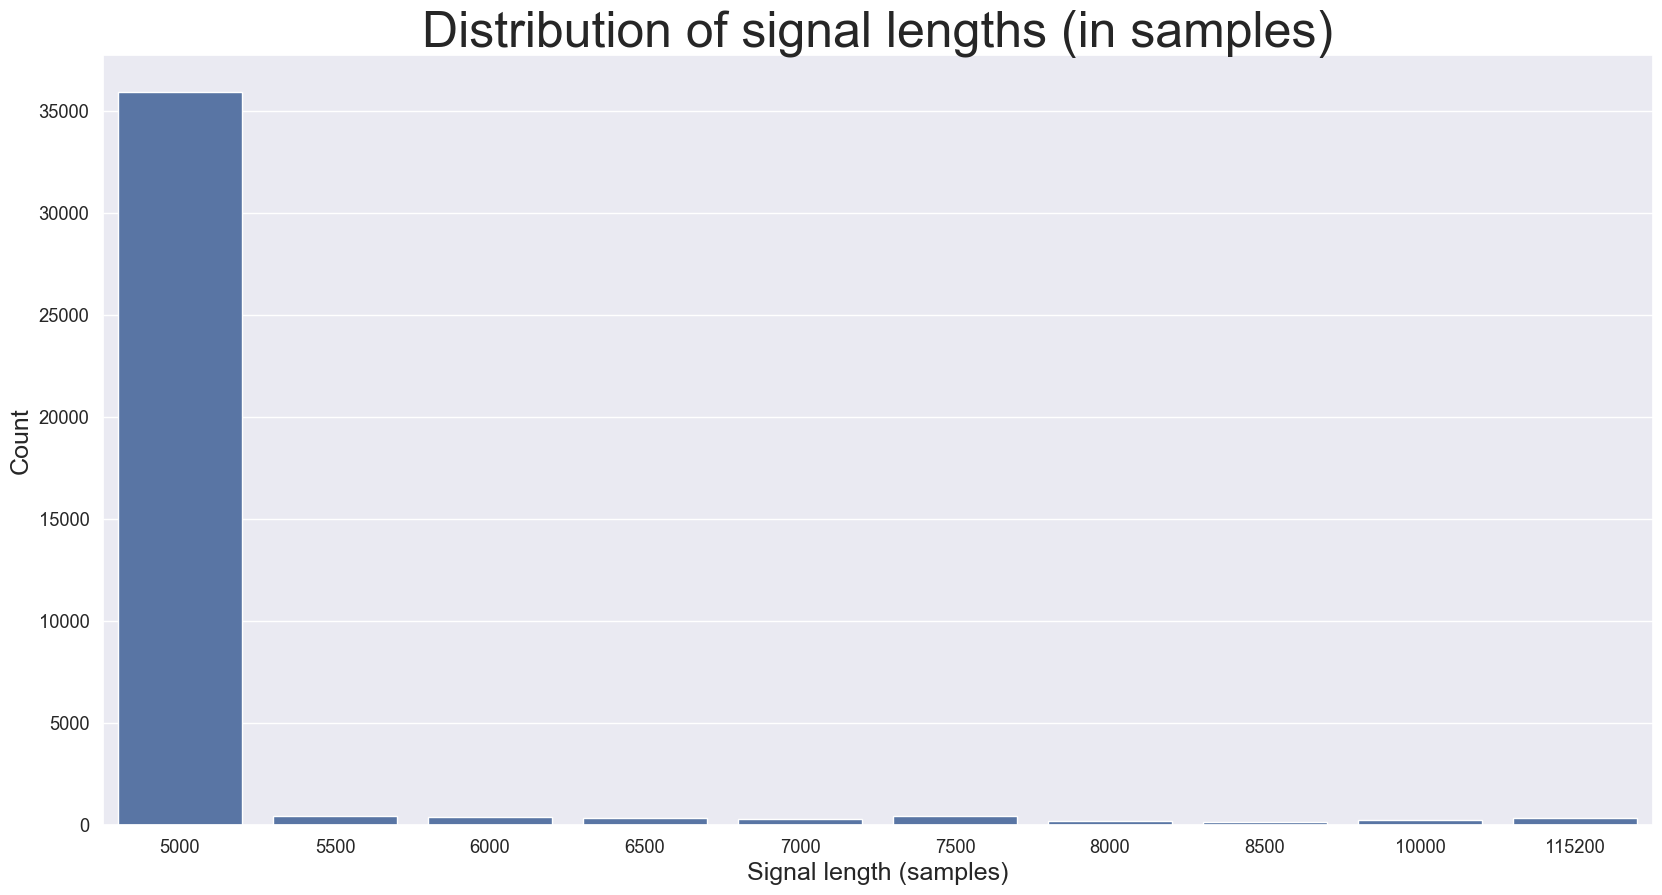

In [130]:
plot_signal_lengths(df, "Distribution of signal lengths (in samples)")

#### All diagnoses are encoded with SNOMED-CT codes. We need a CSV-file to decode them:

In [131]:
SNOMED_scored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_scored.csv", sep=";")
SNOMED_unscored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_unscored.csv", sep=";")

df_labels = pc.make_undefined_class(labels, SNOMED_unscored)

In [132]:
print(df_labels)

                                                       0
0                              undefined class,427084000
1                                        undefined class
2                        undefined class,undefined class
3                        undefined class,undefined class
4                                        undefined class
...                                                  ...
43096    undefined class,undefined class,undefined class
43097  undefined class,undefined class,427084000,unde...
43098  undefined class,undefined class,426627000,6359...
43099  undefined class,427084000,undefined class,unde...
43100  undefined class,426627000,undefined class,unde...

[43101 rows x 1 columns]


#### To be able to feed the labels to a Neural Network we need to OneHot encode the labels

In [133]:
y , snomed_classes = pc.onehot_encode(df_labels)

The classes we will look at are encoded as SNOMED CT codes:
['10370003' '111975006' '164889003' '164890007' '164909002' '164917005'
 '164934002' '164947007' '17338001' '251146004' '270492004' '284470004'
 '39732003' '426177001' '426627000' '426783006' '427084000' '427172004'
 '427393009' '445118002' '47665007' '59118001' '59931005' '63593006'
 '698252002' '713426002' '713427006' 'undefined class']
classes: 27


In [134]:
snomed_abbr = []
for j in range(len(snomed_classes)):
    for i in range(len(SNOMED_scored.iloc[:,1])):
        if (str(SNOMED_scored.iloc[:,1][i]) == snomed_classes[j]):
            snomed_abbr.append(SNOMED_scored.iloc[:,2][i])
            
snomed_abbr = np.asarray(snomed_abbr)

#### The distribution of diagnoses accross the dataset
In the figure under we can see the same SNOMED CT codes decoded into human readable diagnoses on the X-axis. On the Y-axis we have the number of the given diagnoses in the dataset

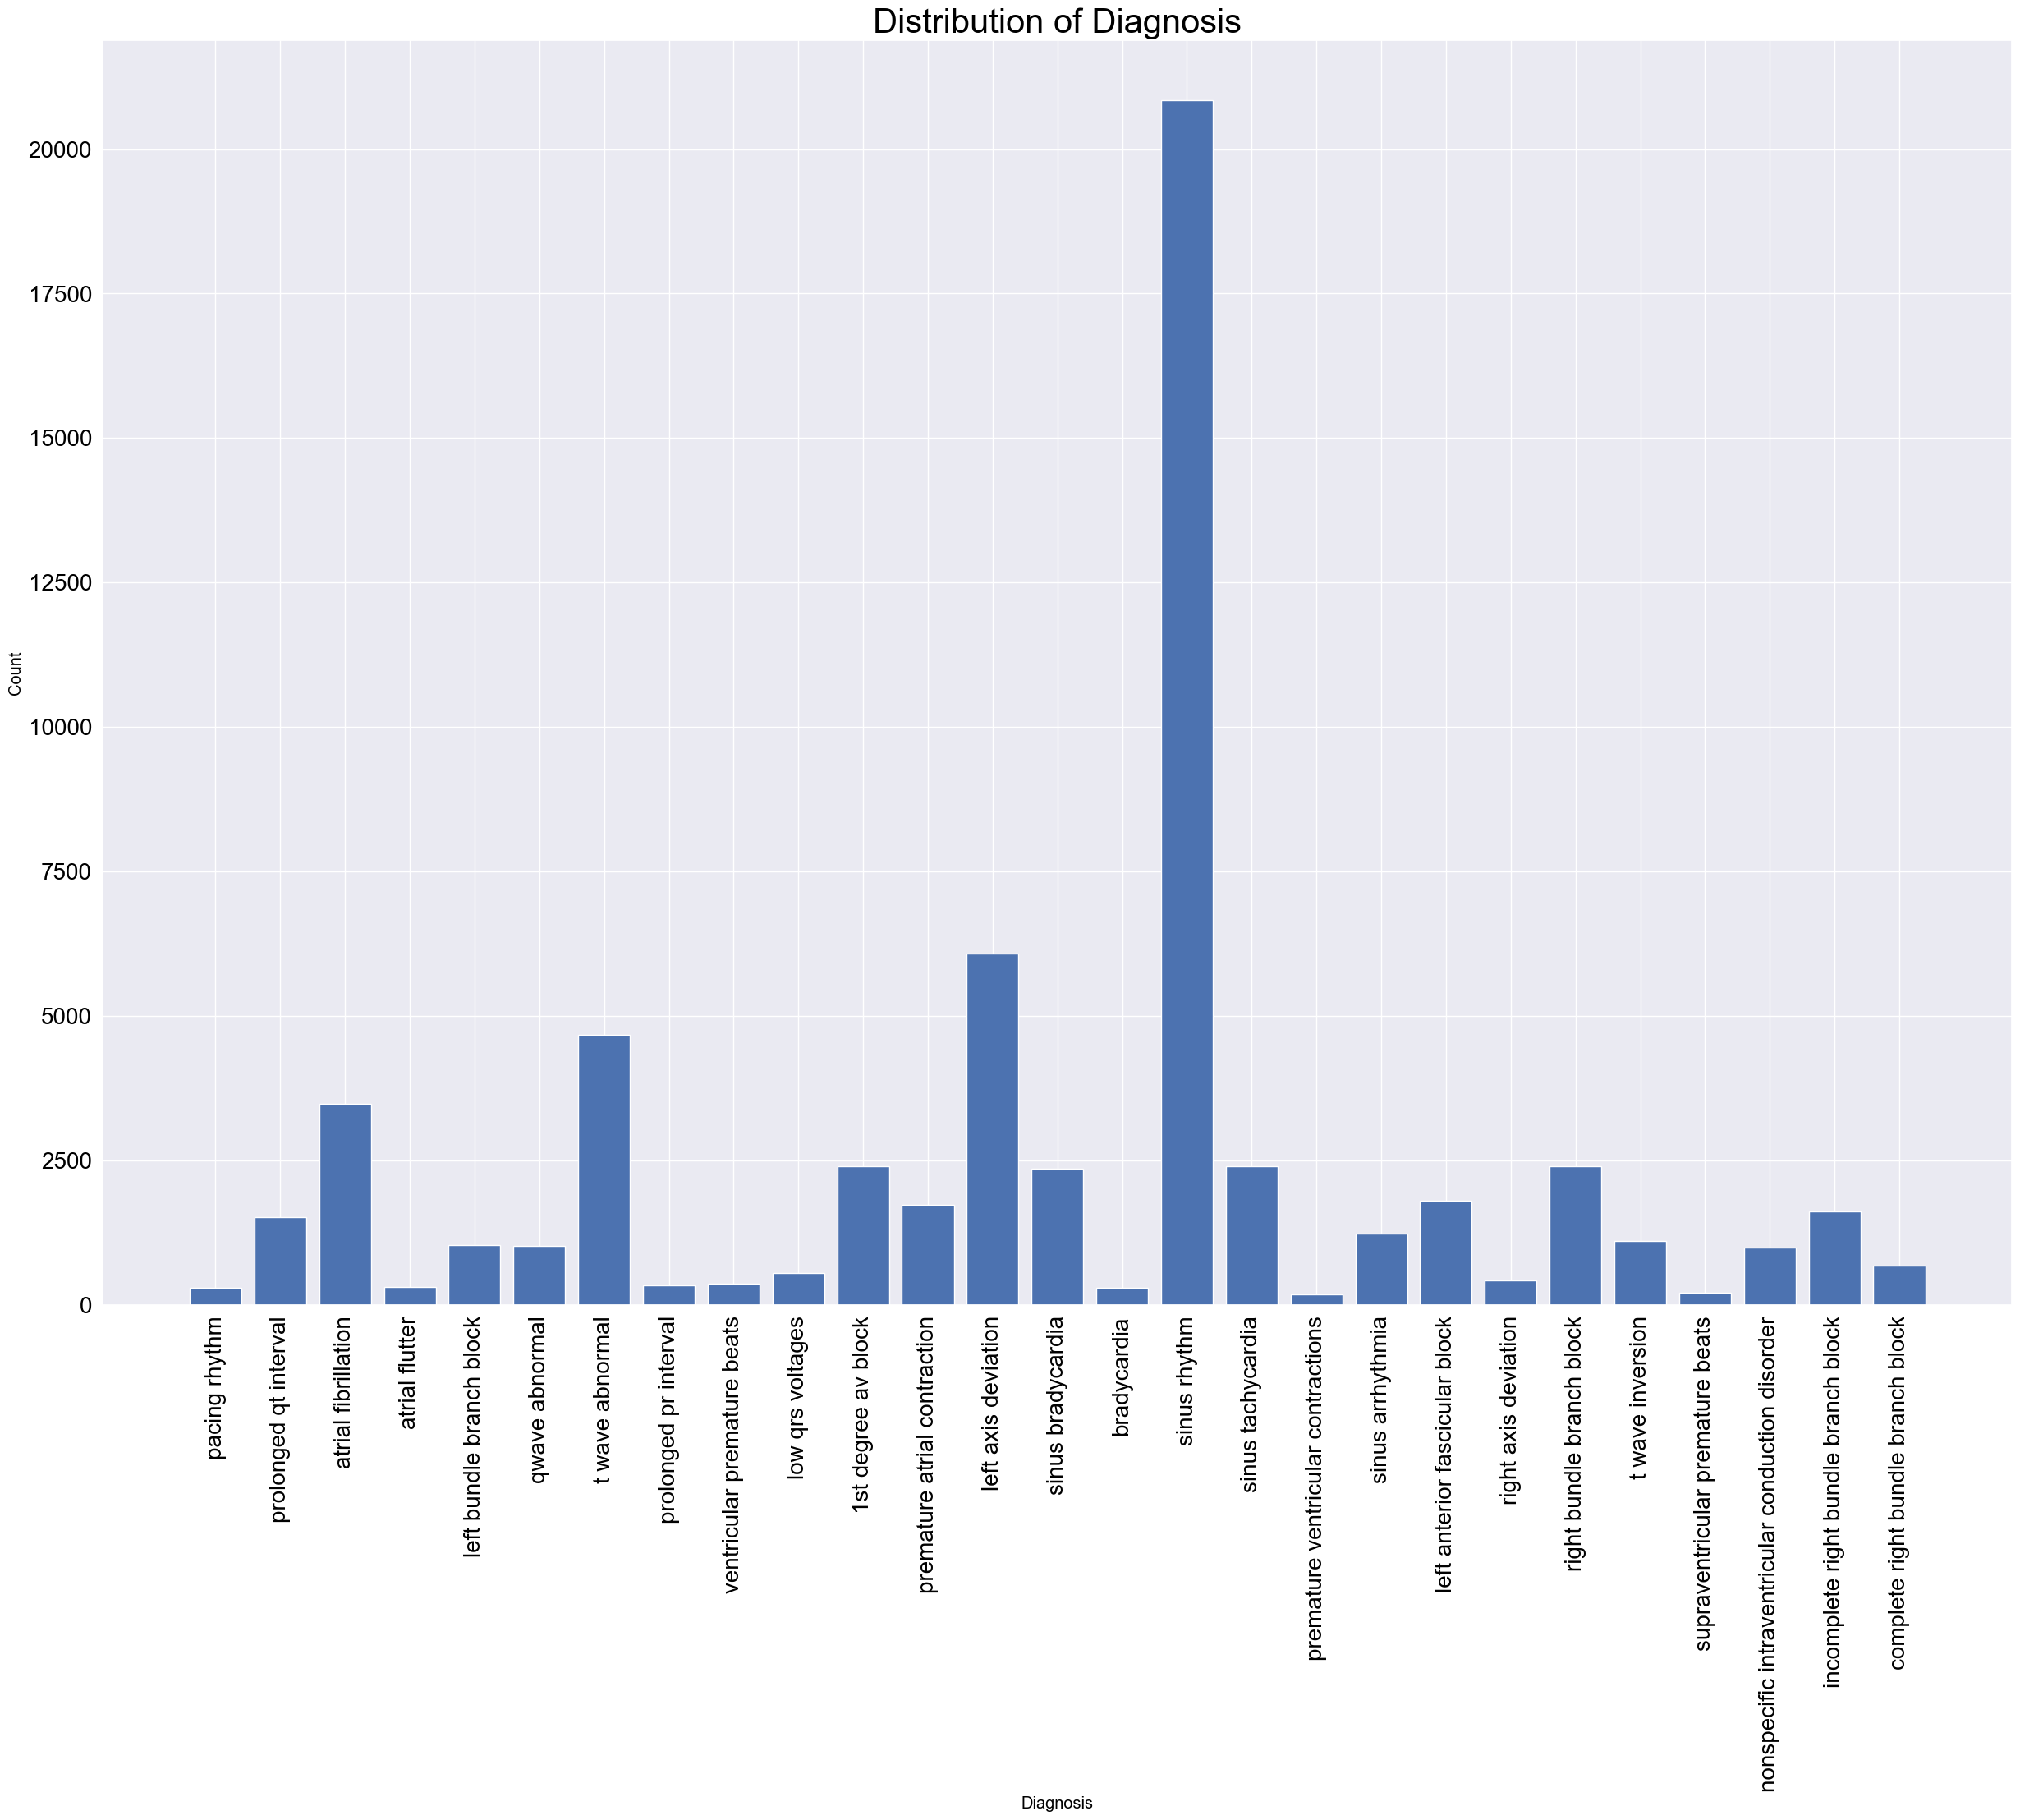

In [135]:
pc.plot_classes(snomed_classes, SNOMED_scored,y)

#### Since this is a multiclass multi-label classification there will be a lot of different combinations of the 27 diagnoses in this study

In [136]:
y_all_comb = pc.get_labels_for_all_combinations(y)
print("Total number of unique combinations of diagnosis: {}".format(len(np.unique(y_all_comb))))

Total number of unique combinations of diagnosis: 1414


#### We will split the data using a 10-fold split with Shuffle=True and random_seed = 42. 
The distribution of Training and Val data in each fold is now:
(in this study we only use the first fold for hold out validation)

In [137]:
folds = pc.split_data(labels, y_all_comb)

Training split: 38790
Validation split: 4311


C:\Users\nares\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\model_selection\_split.py:811: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=10.



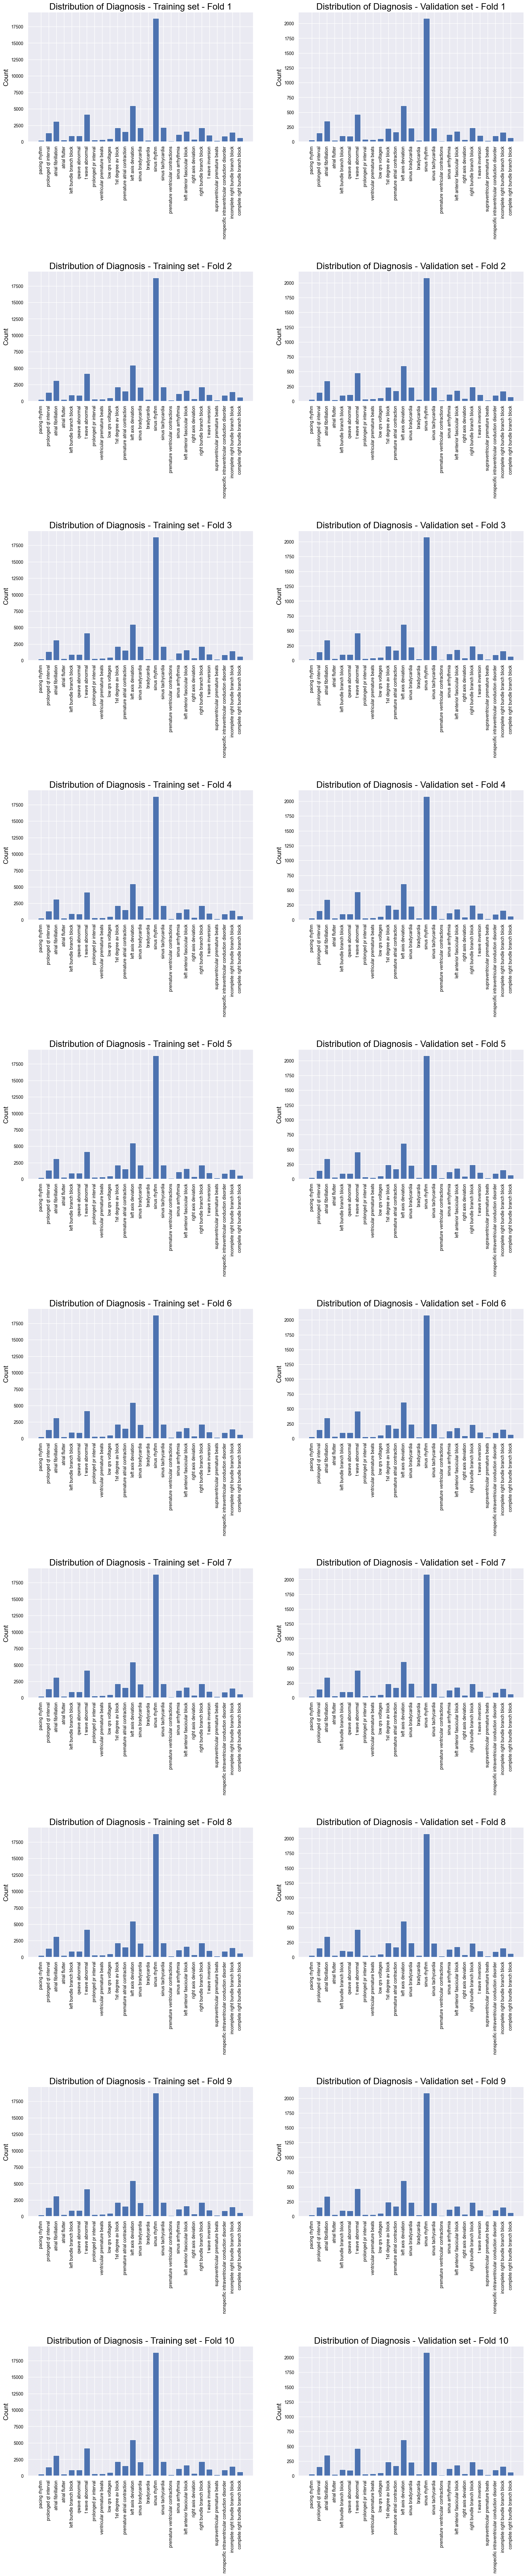

In [138]:
pc.plot_all_folds(folds,y,snomed_classes)

#### Make Batch generators
To feed the Neural Network with a dataset that is too large for our RAM set we need a batch generator to get data into the RAM in batches.
We start by making a "order array" so we can shuffle the order of the data during the training process

In [139]:
order_array = folds[0][0]

In [140]:
def shuffle_batch_generator_demo(batch_size, gen_x,gen_y, gen_z): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    batch_demo_data = np.zeros((batch_size,2))
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            batch_demo_data[i] = next(gen_z)

        X_combined = [batch_features, batch_demo_data]
        yield X_combined, batch_labels
        
def shuffle_batch_generator(batch_size, gen_x,gen_y): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            
        yield batch_features, batch_labels

def generate_y_shuffle(y_train):
    while True:
        for i in order_array:
            y_shuffled = y_train[i]
            yield y_shuffled

def generate_X_shuffle(X_train):
    while True:
        for i in order_array:
                #if filepath.endswith(".mat"):
                    data, header_data = pc.load_challenge_data(X_train[i])
                    X_train_new = pad_sequences(data, maxlen=5000, truncating='post',padding="post")
                    X_train_new = X_train_new.reshape(5000,12)
                    yield X_train_new

def generate_z_shuffle(age_train, gender_train):
    while True:
        for i in order_array:
            gen_age = age_train[i]
            gen_gender = gender_train[i]
            z_train = [gen_age , gen_gender]
            yield z_train

#### Imbalanced data
To compensate for the imbalaced data we calculate a weight for each label. The weight decides how much the Neural Network will learn from the different data labels

In [141]:
new_weights=pc.calculating_class_weights(y)

In [142]:
keys = np.arange(0,27,1)
weight_dictionary = dict(zip(keys, new_weights.T[1]))
weight_dictionary

{0: 72.0752508361204,
 1: 14.243555849306015,
 2: 6.201582733812949,
 3: 68.63216560509554,
 4: 20.701729106628243,
 5: 21.273938795656466,
 6: 4.611705542478066,
 7: 63.383823529411764,
 8: 59.04246575342466,
 9: 38.759892086330936,
 10: 9.00187969924812,
 11: 12.464141122035858,
 12: 3.5409957279000985,
 13: 9.13543874523103,
 14: 74.828125,
 15: 1.0337954523649622,
 16: 8.971898417985013,
 17: 114.63031914893617,
 18: 17.379435483870967,
 19: 11.932724252491694,
 20: 50.469555035128806,
 21: 8.971898417985013,
 22: 19.379946043165468,
 23: 100.23488372093023,
 24: 21.615346038114343,
 25: 13.37709497206704,
 26: 31.552708638360176}

#### Learning rate reduction
To controll the learning rate we use learning rate reduction and early stopping to prevent overfitting

In [143]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_AUC', factor=0.1, patience=1, verbose=1, mode='max',
    min_delta=0.0001, cooldown=0, min_lr=0
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_AUC', mode='max', verbose=1, patience=2)

#### To find the optimal threshold we will use Downhill simplex method

In [ ]:
def thr_chall_metrics(thr, label, output_prob):
    return -pc.compute_challenge_metric_for_opt(label, np.array(output_prob>thr))

### Results

#### Residual Neural Network

In [145]:
model = pc.residual_network_1d()

load a pre-trained model

In [146]:
model.load_weights("data/physionet-challenge-models/resnet_model.h5")

In [147]:
ecg_filenames = np.asarray(ecg_filenames, dtype=object)
y_pred = model.predict(x = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0])

135/135 [==============================] - 99s 734ms/step


In [148]:
init_thresholds = np.arange(0, 1, 0.05)

In [149]:
all_scores = pc.iterate_threshold(y_pred, ecg_filenames, y ,folds[0][1] )

0.1516625863156977
0.3257728585224567
0.34907885319229215
0.28868950738443655
0.181260365067383
0.07488523992867367
-0.030592151530913974
-0.13422631975369734
-0.2242114341113018
-0.3122581976641526
-0.3953465808086114
-0.47448587178946944
-0.5439621181557601
-0.6015332151710997
-0.6651141368699174
-0.7092221508645785
-0.7470735743049693
-0.7760926050516812
-0.8006819928304572
-0.8173020165059404


In [150]:
new_best_thr = optimize.fmin(thr_chall_metrics, 
                                args = (pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1], y_pred), 
                                x0 = init_thresholds[all_scores.argmax()] * np.ones(27))

Optimization terminated successfully.
         Current function value: -0.380630
         Iterations: 302
         Function evaluations: 579


In [151]:
print(pc.compute_challenge_metric_for_opt(pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1],(y_pred>new_best_thr)*1))

0.38063028434382484


Make conf.matrix

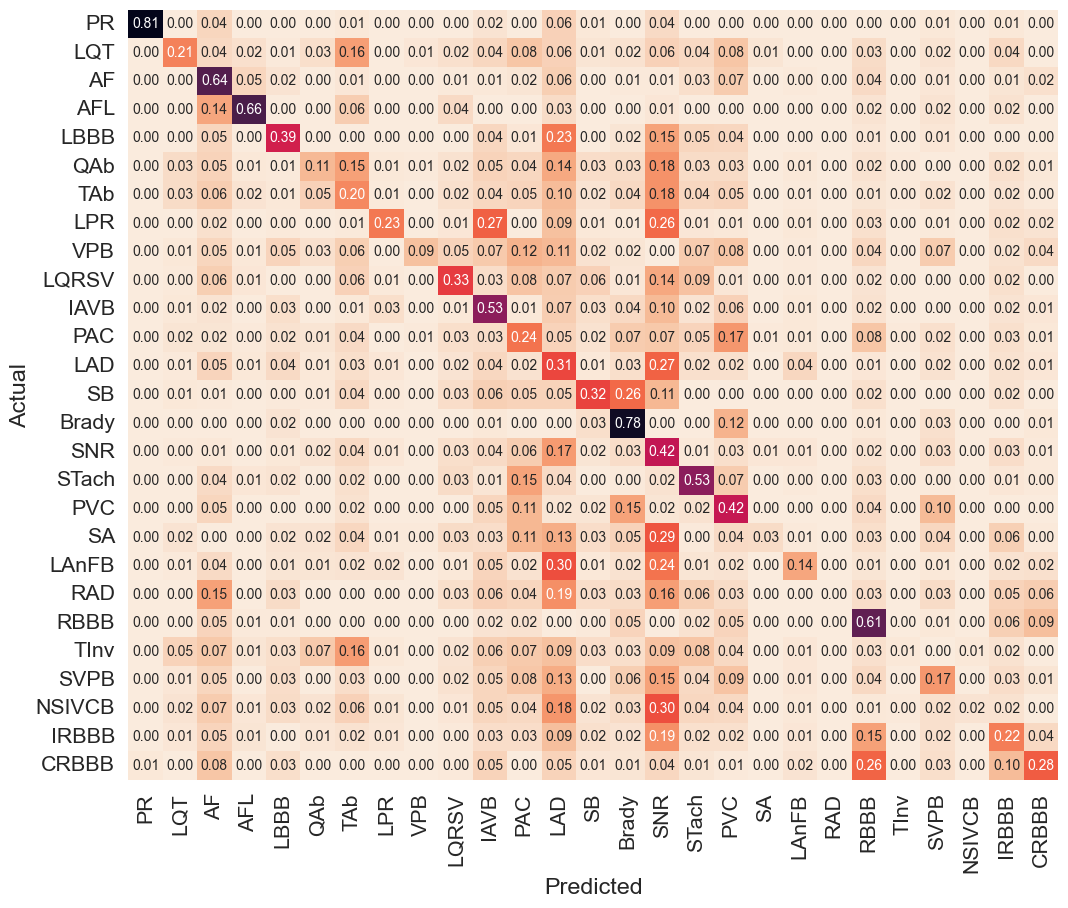

In [152]:
pc.plot_normalized_conf_matrix(y_pred, ecg_filenames, y, folds[0][1], new_best_thr, snomed_classes, snomed_abbr)
plt.savefig("confusion_matrix_resnet.png", dpi=100)

In [153]:
test_aa = pc.generate_validation_data(ecg_filenames,y,folds[0][1])[0]
print(test_aa.shape)

(4311, 5000, 12)


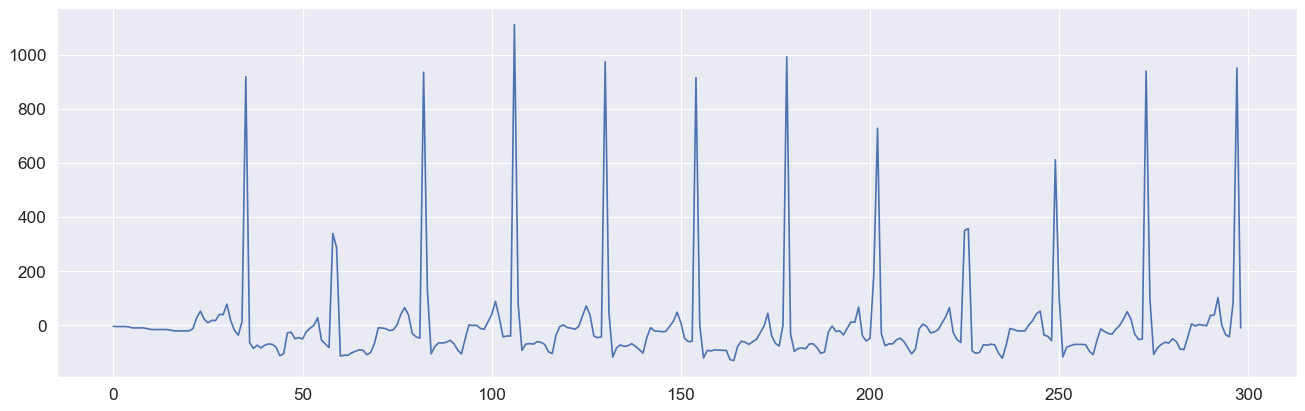

In [ ]:
figure(figsize=(20, 6), dpi=80)
plt.plot(test_aa[0,1:300,1])

In [155]:
y_pred.shape

(4311, 27)

In [156]:
test_aa[:2,:,:].shape

(2, 5000, 12)

In [ ]:
# --- 1) Shim old mixed-precision import path (if you haven't already) ---
try:
    from tensorflow.keras.mixed_precision import LossScaleOptimizer
except Exception:
    try:
        from tensorflow.keras.mixed_precision.experimental import LossScaleOptimizer  # type: ignore
    except Exception:
        class LossScaleOptimizer:  # harmless stub
            pass

mod = types.ModuleType("tensorflow.python.keras.mixed_precision.experimental")
class _LSO: pass
_LSO.LossScaleOptimizer = LossScaleOptimizer
mod.loss_scale_optimizer = _LSO
sys.modules["tensorflow.python.keras.mixed_precision.experimental"] = mod

# --- 2) Ensure optimizer has the legacy flag used by see-rnn ---
if hasattr(model, "optimizer") and not hasattr(model.optimizer, "_HAS_AGGREGATE_GRAD"):
    # False works fine for modern single-replica strategies
    model.optimizer._HAS_AGGREGATE_GRAD = False


(2, 5000, 64)


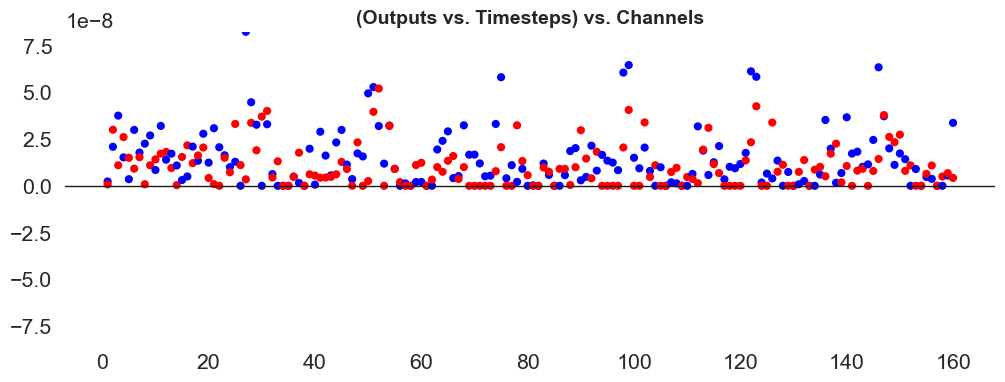

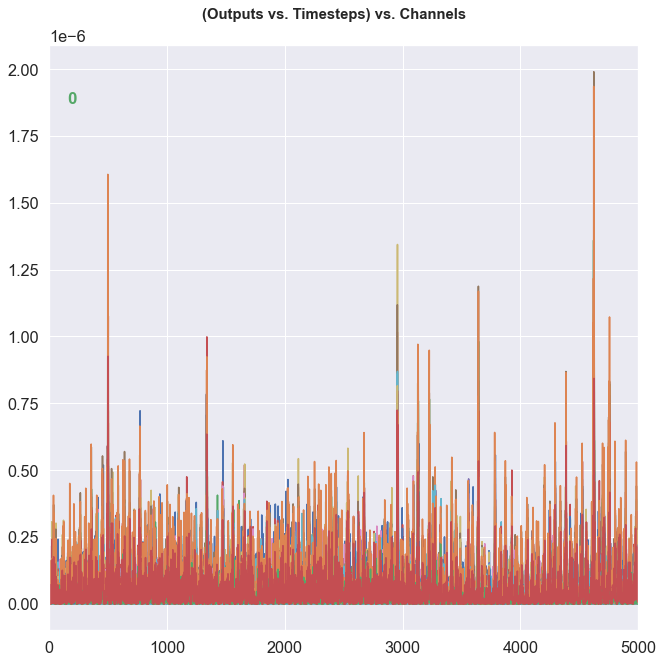

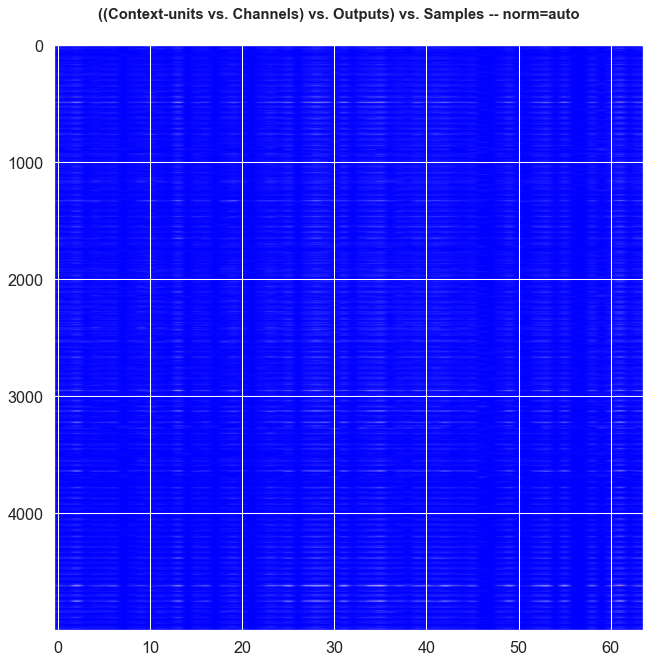

(<Figure size 760x760 with 1 Axes>, array(<Axes: >, dtype=object))

In [ ]:
lidx = 1  # the layer you care about
feat_model = tf.keras.Model(model.inputs, [model.layers[lidx].output, model.output])

x = test_aa[:2, :, :]
y_true = y[:2, :]

with tf.GradientTape() as tape:
    activ, y_hat = feat_model(x, training=False)
    loss_fn = tf.keras.losses.get(model.loss) if hasattr(model, "loss") else tf.keras.losses.CategoricalCrossentropy()
    loss = loss_fn(y_true, y_hat)

grads_all = tape.gradient(loss, activ).numpy()  # shape: (batch, time, features) for recurrent/conv temporal layers

grads_last = grads_all[:, -1, :]   # last timestep slice

outs = get_outputs(model, 1, x)

print(grads_all.shape)

features_0D(np.abs(grads_all[0,0:160,:2]))               # (features,) -> 0D OK
features_1D(np.abs(grads_all[1]), n_rows=4)               # (time, features) -> 2D OK
features_2D(np.abs(grads_all[1]))               # (time, features) -> 2D OK


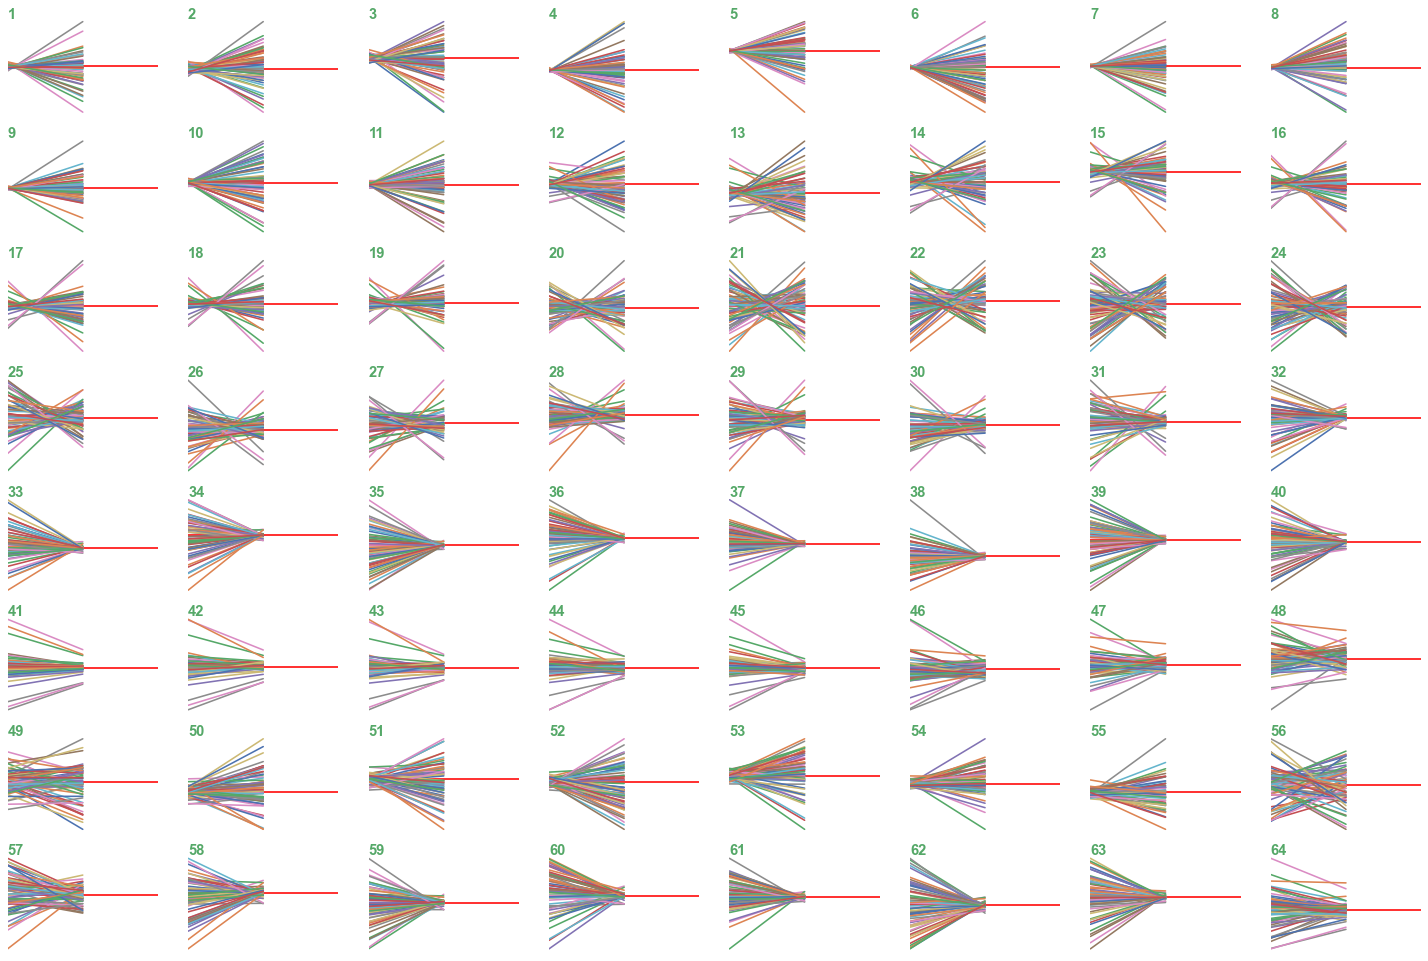

In [161]:
# https://stackoverflow.com/questions/58356868/how-visualize-attention-lstm-using-keras-self-attention-package
def show_features_1D_nv(model=None, layer_name=None, input_data=None,
                     prefetched_outputs=None, max_timesteps=100,
                     max_col_subplots=10, equate_axes=False,
                     show_y_zero=True, channel_axis=-1,
                     scale_width=1, scale_height=1, dpi=76):
    if prefetched_outputs is None:
        layer_outputs = get_layer_outputs(model, layer_name, input_data, 1)[0]
    else:
        layer_outputs = prefetched_outputs
    n_features    = layer_outputs.shape[channel_axis]

    for _int in range(1, max_col_subplots+1):
          if (n_features/_int).is_integer():
                n_cols = int(n_features/_int)
    n_rows = int(n_features/n_cols)

    fig, axes = plt.subplots(n_rows,n_cols,sharey=equate_axes,dpi=dpi)
    fig.set_size_inches(24*scale_width,16*scale_height)

    subplot_idx = 0
    for row_idx in range(axes.shape[0]):
        for col_idx in range(axes.shape[1]): 
            subplot_idx += 1
            feature_output = layer_outputs[:,subplot_idx-1]
            feature_output = feature_output[:max_timesteps]
            ax = axes[row_idx,col_idx]

            if show_y_zero:
                ax.axhline(0,color='red')
            ax.plot(feature_output)

            ax.axis(xmin=0,xmax=len(feature_output))
            ax.axis('off')

            ax.annotate(str(subplot_idx),xy=(0,.99),xycoords='axes fraction',
                        weight='bold',fontsize=14,color='g')
    if equate_axes:
        y_new = []
        for row_axis in axes:
            y_new += [np.max(np.abs([col_axis.get_ylim() for 
                                        col_axis in row_axis]))]
        y_new = np.max(y_new)
        for row_axis in axes:
            [col_axis.set_ylim(-y_new,y_new) for col_axis in row_axis]
    plt.show()

show_features_1D_nv(grads_all, prefetched_outputs = outs)

(2, 5000, 64)


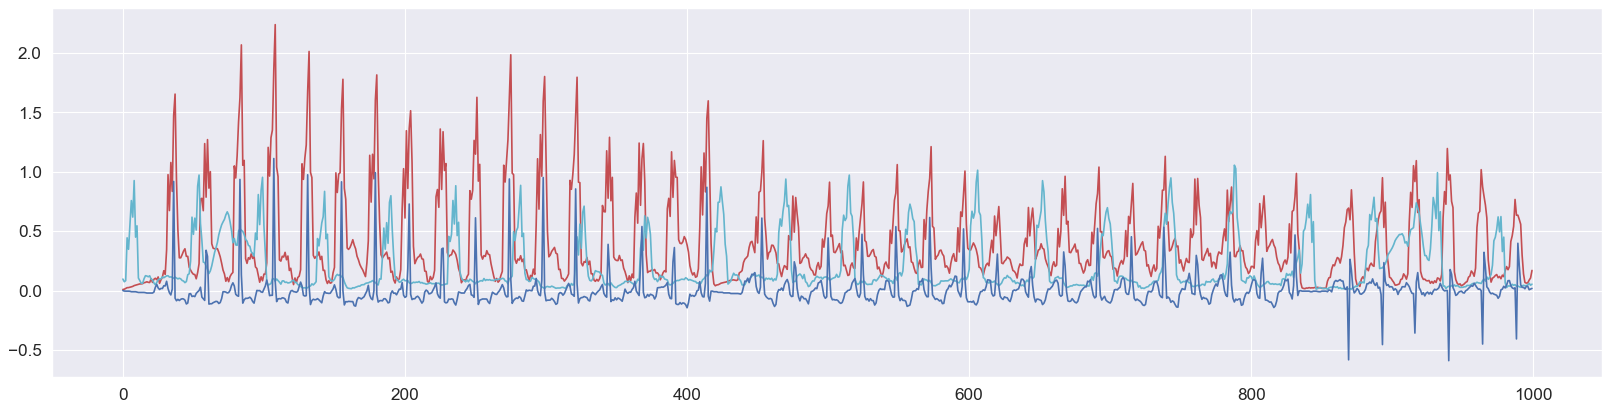

In [162]:
print(grads_all.shape)
end_time = 1000
figure(figsize=(25, 6), dpi=80)
# plt.plot(test_aa[0,1:1000,1]/1000)
plt.plot(pd.DataFrame(outs[0]).max(axis= 1).values[:end_time]/2000,'r')
plt.plot(pd.DataFrame(outs[1]).max(axis= 1).values[:end_time]/2000,'c')
plt.plot(test_aa[0,:end_time,1]/1000)
plt.show()

In [163]:
grads_all.shape

(2, 5000, 64)

In [164]:
pd.DataFrame(grads_all[0,:,:]).abs().max(axis= 1).values[:end_time]*10**13

array([ 699174.12304221,  813100.34261151,  701115.68106768,
        838829.16612765, 1042277.091301  ,  968483.46231582,
        860667.62605697,  936916.10913993,  805788.78680626,
       1020440.33667426,  881653.86102901,  720626.04772327,
        764399.88561106,  602140.48858143,  528329.55788062,
        714369.07944644,  765810.95243   ,  535175.77924822,
        607588.85922496,  571317.92630116,  327391.30517712,
        463145.36206182,  626765.48395757,  386297.71381693,
        644790.31891551,  703564.35344365, 1454598.07754378,
       2210954.76149458, 1454973.52832535,  891608.8489741 ,
       1011938.90600371,  480887.7562823 ,  224875.83350994,
        150719.57903956,  159452.39795201,  150017.42070808,
        184870.57218408,  195363.31663517,  270162.22148291,
        364400.98938328,  364265.27572075,  419266.25726774,
        625414.1737827 ,  549003.40273889, 1077940.51018573,
        875450.25451163,  760440.10199894,  899259.6178814 ,
       1029316.64969219,

In [165]:
sample = np.array(test_aa[0:10]).copy()
sample.shape

(10, 5000, 12)

## Class implementation

In [ ]:
class Telmi:
    def __init__(self,model,data,num_perturbations: int,window_size:int, kernel_width=0.25):
        self.model = model
        self.data = data
        self.num_perturbations = num_perturbations
        self.window_size = window_size
        self.kernel_width = kernel_width
        self.num_features = data.shape[2]
        if len(data.shape) != 3:
            raise ValueError("input Data must be batch of instance")

    def _kernel_func(self, distances):
        return np.sqrt(np.exp(-(distances ** 2) / self.kernel_width ** 2))

    def _instance_feature_explain(self, instance):
        instance = np.array([instance])
        top_class = model.predict(instance)[0].argsort()
        perturbations_sets = self._create_perturbations_sets(self.num_perturbations,self.num_features)
        perturb_instance_predictions = np.array([model.predict(subset * instance) for subset in perturbations_sets])
        original_instance = np.ones(self.num_features)[np.newaxis,:]
        distances = sklearn.metrics.pairwise_distances(perturbations_sets,original_instance, metric='cosine').ravel()
        weights = self._kernel_func(distances)
        surrogate_model = LinearRegression()
        surrogate_model.fit(perturbations_sets, perturb_instance_predictions[:,:,top_class[-1]], sample_weight=weights)
        return surrogate_model.coef_[0]
    
    def _instance_event_explain(self, instance):
        instance = np.array([instance])
        top_class = model.predict(instance)[0].argsort()
        num_events = int(np.ceil(instance.shape[1] / self.window_size))
        events = list(self._create_event_chunks(instance[0].copy(),num_events))
        perturbations_sets = self._create_perturbations_sets(self.num_perturbations,num_events)
        perturb_events_predictions = []
        for subset in perturbations_sets:
            perturb_events = np.array(list(map(lambda x:x[0] * x[1], zip(events,subset))))
            perturb_events_predictions.append(model.predict(perturb_events))
        perturb_events_predictions = np.array(perturb_events_predictions)
        original_instance = np.ones(num_events)[np.newaxis,:]
        distances = sklearn.metrics.pairwise_distances(perturbations_sets,original_instance, metric='cosine').ravel()
        weights = self._kernel_func(distances)
        surrogate_model = LinearRegression()
        surrogate_model.fit(perturbations_sets, perturb_events_predictions[:,:,top_class[-1]], sample_weight=weights)
        return surrogate_model.coef_[0]

    def feature_explain(self):
        return np.array(list(map(self._instance_feature_explain,self.data)))
    
    def event_explain(self):
        return np.array(list(map(self._instance_event_explain,self.data)))
    
    @staticmethod
    def _create_perturbations_sets(m: int, n: int):
        perturbations_sets = list(map(list, itertools.product([0, 1], repeat=n)))
        if m==-1 or m==2**n:
            return np.array(perturbations_sets)
        random_index = np.random.choice(len(perturbations_sets), m, replace=False)
        random_perturbations_sets = [perturbations_sets[i] for i in random_index]
        return np.array(random_perturbations_sets)


    @staticmethod
    def _create_event_chunks(instance, num_chunks: int):
        for i in range(0, len(instance), num_chunks):
            yield instance[i:i+num_chunks]   


In [167]:
x = Telmi(model,sample,200,500)

In [168]:
x.feature_explain()

1/1 [==============================] - 0s 47ms/step


array([[ 2.35670085e-02,  8.82565762e-02,  8.13463610e-02,
         4.25201069e-02,  6.31497027e-02,  3.80698561e-02,
        -7.40787524e-03,  6.34720387e-02,  1.05417097e-01,
         7.79252392e-03, -7.88938759e-03,  6.75702789e-02],
       [-1.72253367e-03, -2.67720454e-03, -6.40246499e-03,
         4.23438905e-03,  1.33545626e-03,  3.65851609e-03,
        -2.71010894e-03,  6.07797990e-03, -2.32066671e-03,
         5.46172444e-03,  5.84489735e-03, -3.38607003e-03],
       [-5.62886430e-03,  2.53714103e-03,  2.03895453e-03,
         2.07423872e-02,  4.35803592e-03,  1.83700373e-02,
        -8.32698105e-04,  1.31791711e-02,  6.03883776e-03,
         1.61118720e-02,  8.01036770e-03,  7.99231900e-03],
       [-5.53211853e-04, -4.89586539e-04, -8.87877512e-04,
         7.35922453e-04,  4.42204570e-04,  9.21782784e-04,
         4.80301381e-05, -3.40342808e-05, -1.27312060e-03,
         1.19860727e-03,  9.08113144e-04, -3.61091009e-04],
       [ 1.88942556e-02,  5.80935821e-02,  3.6962736

In [169]:
x.event_explain()

1/1 [==============================] - 0s 20ms/step


array([[-8.13917504e-05,  1.03158412e-20, -8.52168558e-21,
         4.49311514e-20,  5.74854396e-21,  1.09993909e-20,
        -1.59883690e-20, -7.43154689e-21,  4.84534088e-20,
         7.42612534e-21],
       [-2.13852551e-01,  6.10332274e-17, -2.14489532e-18,
        -4.57164046e-18,  2.37928350e-17, -7.02150512e-17,
         4.86192040e-17,  4.07460755e-18,  1.08028326e-17,
         1.17045357e-17],
       [ 3.54288518e-03,  4.08630907e-19,  3.52444648e-18,
         2.26708109e-18,  2.89277682e-18, -5.68095469e-18,
         1.74929141e-18,  1.26164823e-18, -2.72663117e-18,
        -1.35291402e-19],
       [ 7.75011750e-02, -8.06582071e-18,  2.74590056e-17,
        -1.21691987e-17, -1.18446146e-17,  8.99605508e-18,
        -2.67304859e-17,  4.46497299e-17, -7.50476434e-18,
        -1.77219483e-17],
       [ 4.40487154e-02,  8.58684300e-18, -5.39018317e-17,
         2.10285945e-17, -9.06614308e-18,  3.08250257e-17,
         2.46322173e-17, -2.82939178e-17, -2.81060276e-17,
        -1.

## Feature explain

In [171]:
sample_prediction = model.predict(sample)

1/1 [==============================] - 0s 250ms/step


In [172]:
top_classes = sample_prediction[0].argsort()

In [173]:
top_classes

array([13,  7,  0,  9, 26, 10, 19,  3,  4, 20,  2, 12, 18, 14, 25, 21, 15,
        1, 24, 23,  8, 22,  6,  5, 17, 11, 16], dtype=int64)

In [174]:
num_perturbations = 200
num_feature = 12
perturbations = np.random.binomial(1, 0.5, size=(num_perturbations, num_feature))
perturbations

array([[1, 1, 1, ..., 1, 0, 0],
       [1, 1, 0, ..., 0, 0, 1],
       [1, 1, 0, ..., 0, 0, 1],
       ...,
       [0, 1, 0, ..., 0, 1, 1],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 1, 0]])

In [175]:
perturb_prediction = []
distance = []
for subset in perturbations:
    data = sample * subset
    perturb_prediction.append(model.predict(data))
perturb_prediction = np.array(perturb_prediction)

1/1 [==============================] - 0s 254ms/step


In [176]:
perturb_prediction.shape


(200, 10, 27)

In [177]:
original_instance = np.ones(num_feature)[np.newaxis,:]
distances = sklearn.metrics.pairwise_distances(perturbations,original_instance, metric='cosine').ravel()
distances.shape

(200,)

In [178]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2))
weights.shape

(200,)

In [179]:
class_to_explain = top_classes[-1]
surrogate_model = LinearRegression()
surrogate_model.fit(X=perturbations, y=perturb_prediction[:,:,class_to_explain], sample_weight=weights)
coeff = surrogate_model.coef_[0]
coeff

array([ 0.02690135,  0.08666224,  0.06915932,  0.05587694,  0.05715158,
        0.07994873, -0.00888631,  0.05436183,  0.11739733,  0.03852603,
        0.03632872,  0.02100463])

In [ ]:
Coeff_df = pd.DataFrame()

Coeff_df['TELMI'] = coeff

fig = px.bar(Coeff_df, x=Coeff_df['TELMI'], y= Coeff_df.index, orientation='h', color=Coeff_df.index)
fig.show()

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [ ]:
fig = go.Figure(go.Waterfall(
    name = "20", 
    orientation = "h",
    x = Coeff_df['TELMI'],
    textposition = "outside",
    y = Coeff_df['TELMI'].index,    
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
))

fig.update_layout(
        title = "TELMI Explanability",
        showlegend = True
)

fig.show()

## event explain

In [182]:
sample = np.array([test_aa[0]])

In [183]:
num_perturbations = 200
num_feature = 10
perturbations = np.random.binomial(1, 0.5, size=(num_perturbations, num_feature))
perturbations

array([[0, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 1, 1, ..., 1, 1, 0],
       ...,
       [0, 0, 1, ..., 0, 1, 1],
       [1, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 1, 1, 0]])

In [184]:
reshaped_sample = sample.reshape((5000,12)).copy()

In [185]:
perturb_prediction = []
distance = []
for subset in perturbations:
    reshaped_sample = sample.reshape((5000,12)).copy()
    splited_event = np.array_split(reshaped_sample,10)
    for idx, value in enumerate(subset):
        if value == 0:
            splited_event[idx][:,:] = 0
    perturb_prediction.append(model.predict(np.array(splited_event)))
perturb_prediction = np.array(perturb_prediction)

1/1 [==============================] - 0s 49ms/step


In [186]:
original_instance = np.ones(num_feature)[np.newaxis,:]
distances = sklearn.metrics.pairwise_distances(perturbations,original_instance, metric='cosine').ravel()
distances.shape

(200,)

In [187]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2))
weights.shape

(200,)

In [188]:
class_to_explain = top_classes[-1]
surrogate_model = LinearRegression()
surrogate_model.fit(X=perturbations, y=perturb_prediction[:,:,class_to_explain], sample_weight=weights)
coeff = surrogate_model.coef_[0]
coeff

array([ 1.63374348e-01,  8.57536379e-18, -1.25315122e-17, -2.42612902e-19,
       -1.44890316e-17, -3.88752951e-17,  4.61516224e-17, -4.02682040e-18,
       -4.49352448e-18, -5.10432282e-17])

### SHAP Analysis

In [ ]:
def prepare_ecg(filepath, maxlen=5000):
    data, header = pc.load_challenge_data(filepath)  # shape: (12, variable_length)
    data = np.array(data).T  # shape: (length, 12)
    data = pad_sequences([data], maxlen=maxlen, padding='post', truncating='post', dtype='float32')  # shape: (1, maxlen, 12)
    return data

In [190]:
# Load ECG input (already using your utility function)
ecg_file = "data/china-12lead-ecg-challenge-database/Training_2/Q0002.mat"
sample_input = prepare_ecg(ecg_file)

# Background data for SHAP
background = np.vstack([prepare_ecg(f) for f in ecg_filenames[:50]])  # Use 50 or fewer to save memory

# Create the SHAP Gradient Explainer
explainer = shap.GradientExplainer(model, background)

# Get SHAP values for your sample
shap_values = explainer.shap_values(sample_input)

C:\Users\nares\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\backend.py:452: UserWarning:

`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.



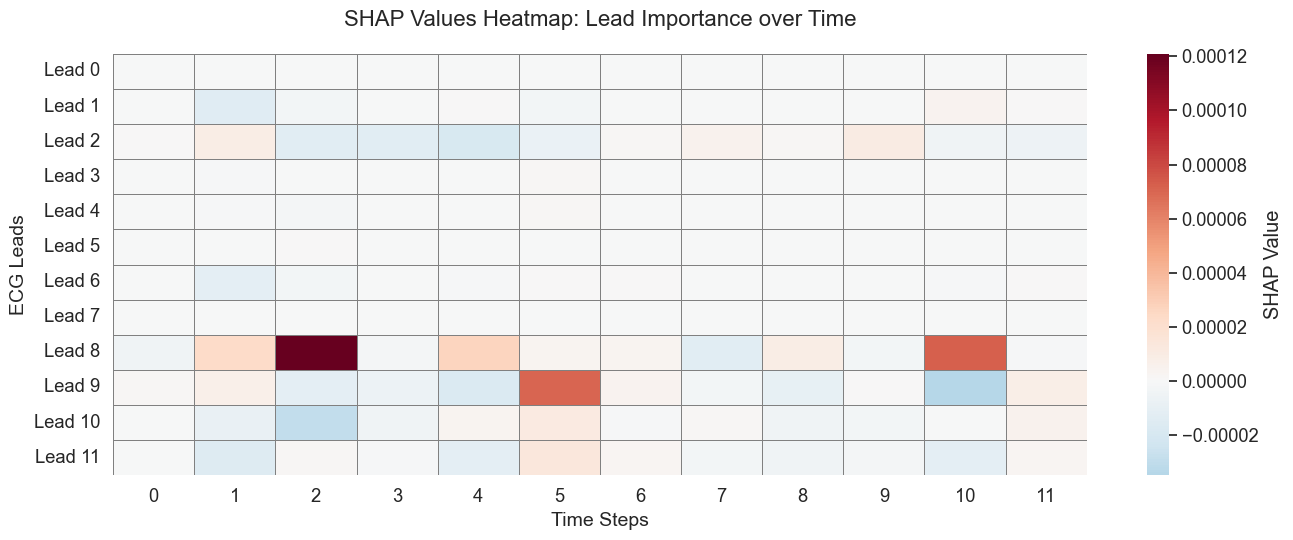

In [191]:
# shap_values[0][0] has shape (5000, 12), but you're showing a slice (e.g., first 12 time steps)
heatmap_data = shap_values[0][0][:, :12].T  # shape (12 leads, 12 time steps)

plt.figure(figsize=(14, 6))
sns.set_theme(font_scale=1.2)
sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'SHAP Value'},
    xticklabels=range(heatmap_data.shape[1]),
    yticklabels=[f"Lead {i}" for i in range(heatmap_data.shape[0])],
    linewidths=0.5,
    linecolor='gray'
)

plt.title("SHAP Values Heatmap: Lead Importance over Time", fontsize=16, pad=20)
plt.xlabel("Time Steps", fontsize=14)
plt.ylabel("ECG Leads", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout(pad=2.0)
plt.show()


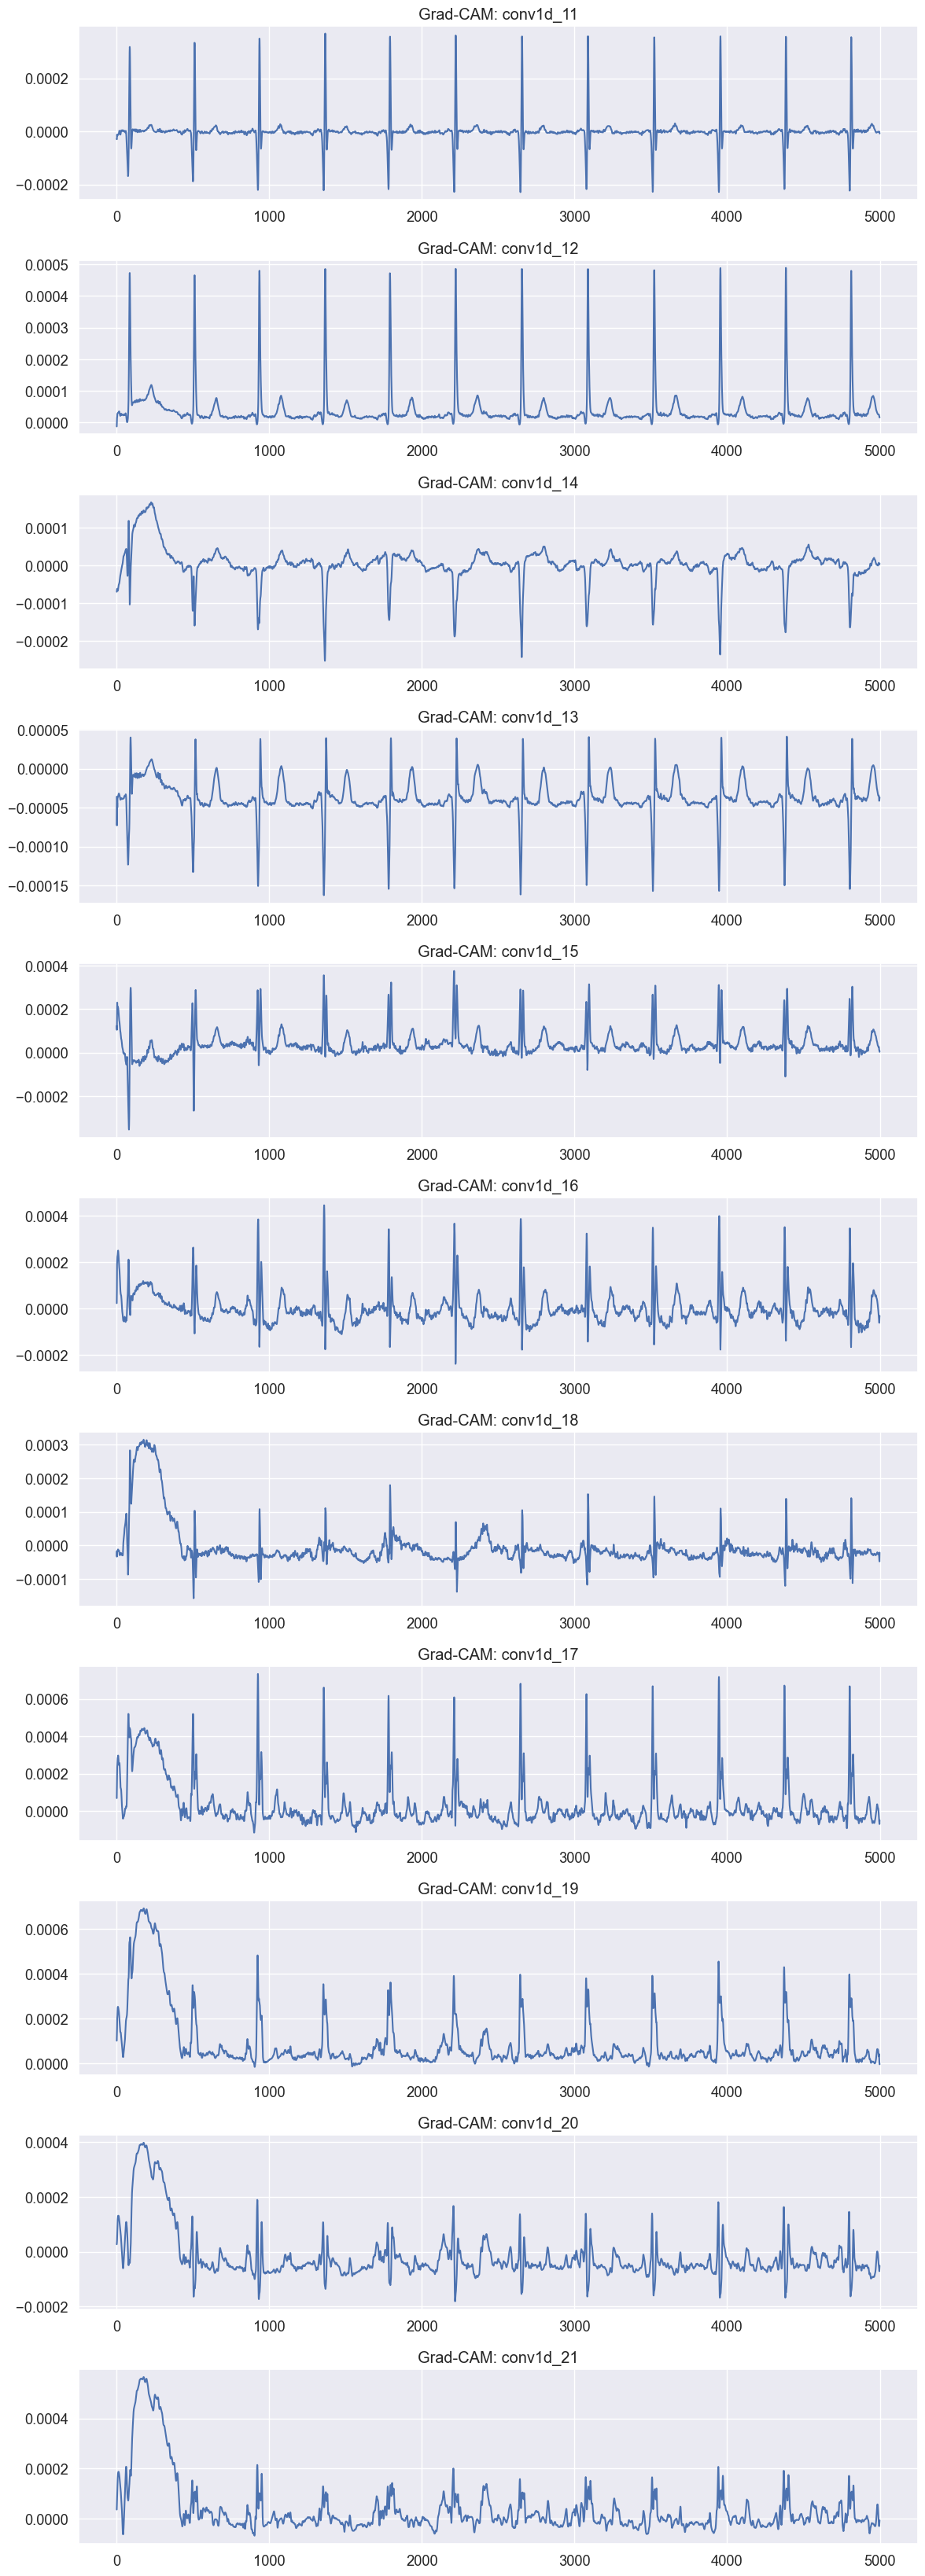

In [192]:
def grad_cam_1d(model, input_data, layer_name):
    """
    Compute Grad-CAM for a specific 1D layer.
    """
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        inputs = tf.cast(input_data, tf.float32)
        conv_outputs, predictions = grad_model(inputs)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    
    # Global average pooling over time dimension
    weights = tf.reduce_mean(grads, axis=1)
    
    # Weighted sum
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, :], conv_outputs), axis=-1)
    return cam.numpy()


def grad_cam_all_layers(model, input_data, layer_types=(tf.keras.layers.Conv1D,)):
    """
    Compute Grad-CAM for all layers of given types (default: Conv1D).
    Returns a dict of {layer_name: cam_output}.
    """
    cams = {}
    
    for layer in model.layers:
        if isinstance(layer, layer_types):
            try:
                cam = grad_cam_1d(model, input_data, layer.name)
                cams[layer.name] = cam
            except Exception as e:
                print(f"Skipping {layer.name} due to error: {e}")
    
    return cams


def plot_grad_cams(cams, sample_idx=0):
    """
    Plot Grad-CAM heatmaps for a given sample across all layers.
    """
    n_layers = len(cams)
    plt.figure(figsize=(12, 3 * n_layers))
    
    for i, (layer_name, cam) in enumerate(cams.items(), 1):
        plt.subplot(n_layers, 1, i)
        plt.plot(cam[sample_idx])
        plt.title(f"Grad-CAM: {layer_name}")
    
    plt.tight_layout()
    plt.show()


# Usage example
sample_input = prepare_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0002.mat")
cams = grad_cam_all_layers(model, sample_input)

plot_grad_cams(cams, sample_idx=0)



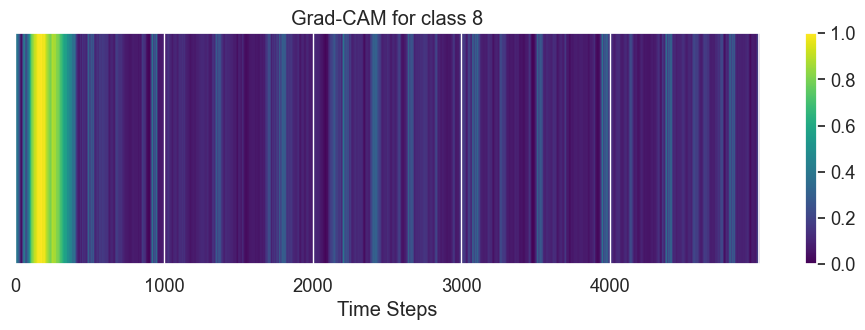

In [198]:
# build model to output last conv layer + predictions
# find last Conv1D layer
conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv1D)]
if not conv_layers:
    raise ValueError("No Conv1D layers found in model.")

last_conv = conv_layers[-1]

grad_model = tf.keras.Model([model.inputs], [last_conv.output, model.output])

# forward + backward pass
with tf.GradientTape() as tape:
    conv_out, preds = grad_model(sample_input)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

# compute gradients wrt conv features
grads = tape.gradient(loss, conv_out)
weights = tf.reduce_mean(grads, axis=1)   # average over time axis
cam = tf.reduce_sum(tf.multiply(weights, conv_out), axis=-1)

# normalize CAM
cam = cam[0].numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min())

# plot heatmap
plt.figure(figsize=(12, 3))
plt.imshow(cam[np.newaxis, :], aspect="auto", cmap="viridis")
plt.title(f"Grad-CAM for class {class_idx.numpy()}")
plt.xlabel("Time Steps")
plt.yticks([])
plt.colorbar()
plt.show()


In [200]:
x = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0]

In [201]:
print(x.shape)

(4311, 5000, 12)


In [ ]:
# 1) Find ECG batch from common names (X_test, X_val, signals, etc.)
ecg_raw, ecg_varname = find_ecg_batch(globals())
ecg_batch = to_batch_L_T(x)        # (B, L, T)
fs = 500     # or set fs = 500

# 2) Choose a sample
idx = 0
ecg_single = ecg_batch[idx]              # (L, T)

# 3) Wrap your Keras model
predict_fn = make_keras_predict_fn(model, expects_time_lead=True)

# 4) Attribution
# If you don't already have attributions, compute IG as a fallback:
probs = predict_fn(ecg_single[None, ...])
class_index = int(np.argmax(probs[0]))
attr_single = integrated_gradients_keras(model, ecg_single, target_index=class_index)  # (L, T)

## Clinically-aligned attribution: per-lead, per-wave

In [203]:
lead_wave = lead_wave_table(attr_single, ecg_single, fs)
lead_wave

{'lead_1': {'P': 0.21090971203894954,
  'QRS': 0.32495139410311275,
  'ST': 0.08748192608797734,
  'T': 0.37665683441201153},
 'lead_2': {'P': 0.22928809583325088,
  'QRS': 0.2970983019806268,
  'ST': 0.10354172040134217,
  'T': 0.37007163405195526},
 'lead_3': {'P': 0.22957060694644138,
  'QRS': 0.31562255174518017,
  'ST': 0.1055109212866199,
  'T': 0.3492958245174797},
 'lead_4': {'P': 0.25113943061889593,
  'QRS': 0.28833550130940944,
  'ST': 0.09753235987165712,
  'T': 0.3629924949332501},
 'lead_5': {'P': 0.25580984299529075,
  'QRS': 0.28693647036162934,
  'ST': 0.10298755500826177,
  'T': 0.35426592916125593},
 'lead_6': {'P': 0.2833360046406165,
  'QRS': 0.23839695664753702,
  'ST': 0.09846230495284253,
  'T': 0.3798046117903181},
 'lead_7': {'P': 0.2794397399600213,
  'QRS': 0.24635730892616356,
  'ST': 0.09759812821977351,
  'T': 0.3766046829732154},
 'lead_8': {'P': 0.27814920670060883,
  'QRS': 0.25205853374877824,
  'ST': 0.1020420118148652,
  'T': 0.36775009452237234},
 

## Faithfulness curves (Insertion/Deletion AUC)

Insertion AUC: 0.02420815200544894
Deletion AUC: 0.019123974135145546


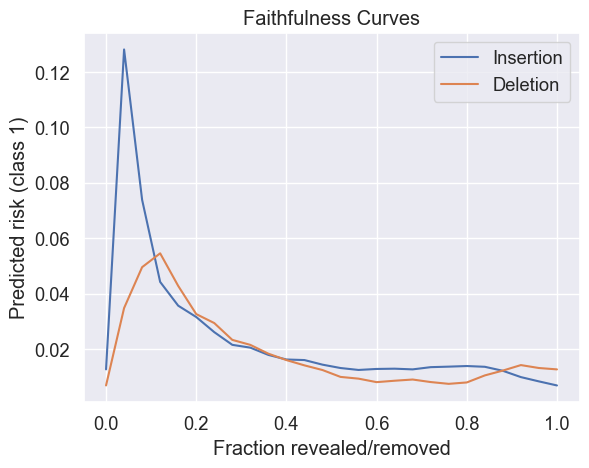

In [204]:
fra, scr, auc_ins = insertion_deletion_auc(predict_fn, ecg_single, attr_single, class_index=1, steps=25, mode='insertion', baseline=0.0)
fra2, scr2, auc_del = insertion_deletion_auc(predict_fn, ecg_single, attr_single, class_index=1, steps=25, mode='deletion', baseline=0.0)

print('Insertion AUC:', auc_ins)
print('Deletion AUC:', auc_del)

plt.figure()
plt.plot(fra, scr, label='Insertion')
plt.plot(fra2, scr2, label='Deletion')
plt.xlabel('Fraction revealed/removed')
plt.ylabel('Predicted risk (class 1)')
plt.legend()
plt.title('Faithfulness Curves')
plt.show()

## Simple overlay plot

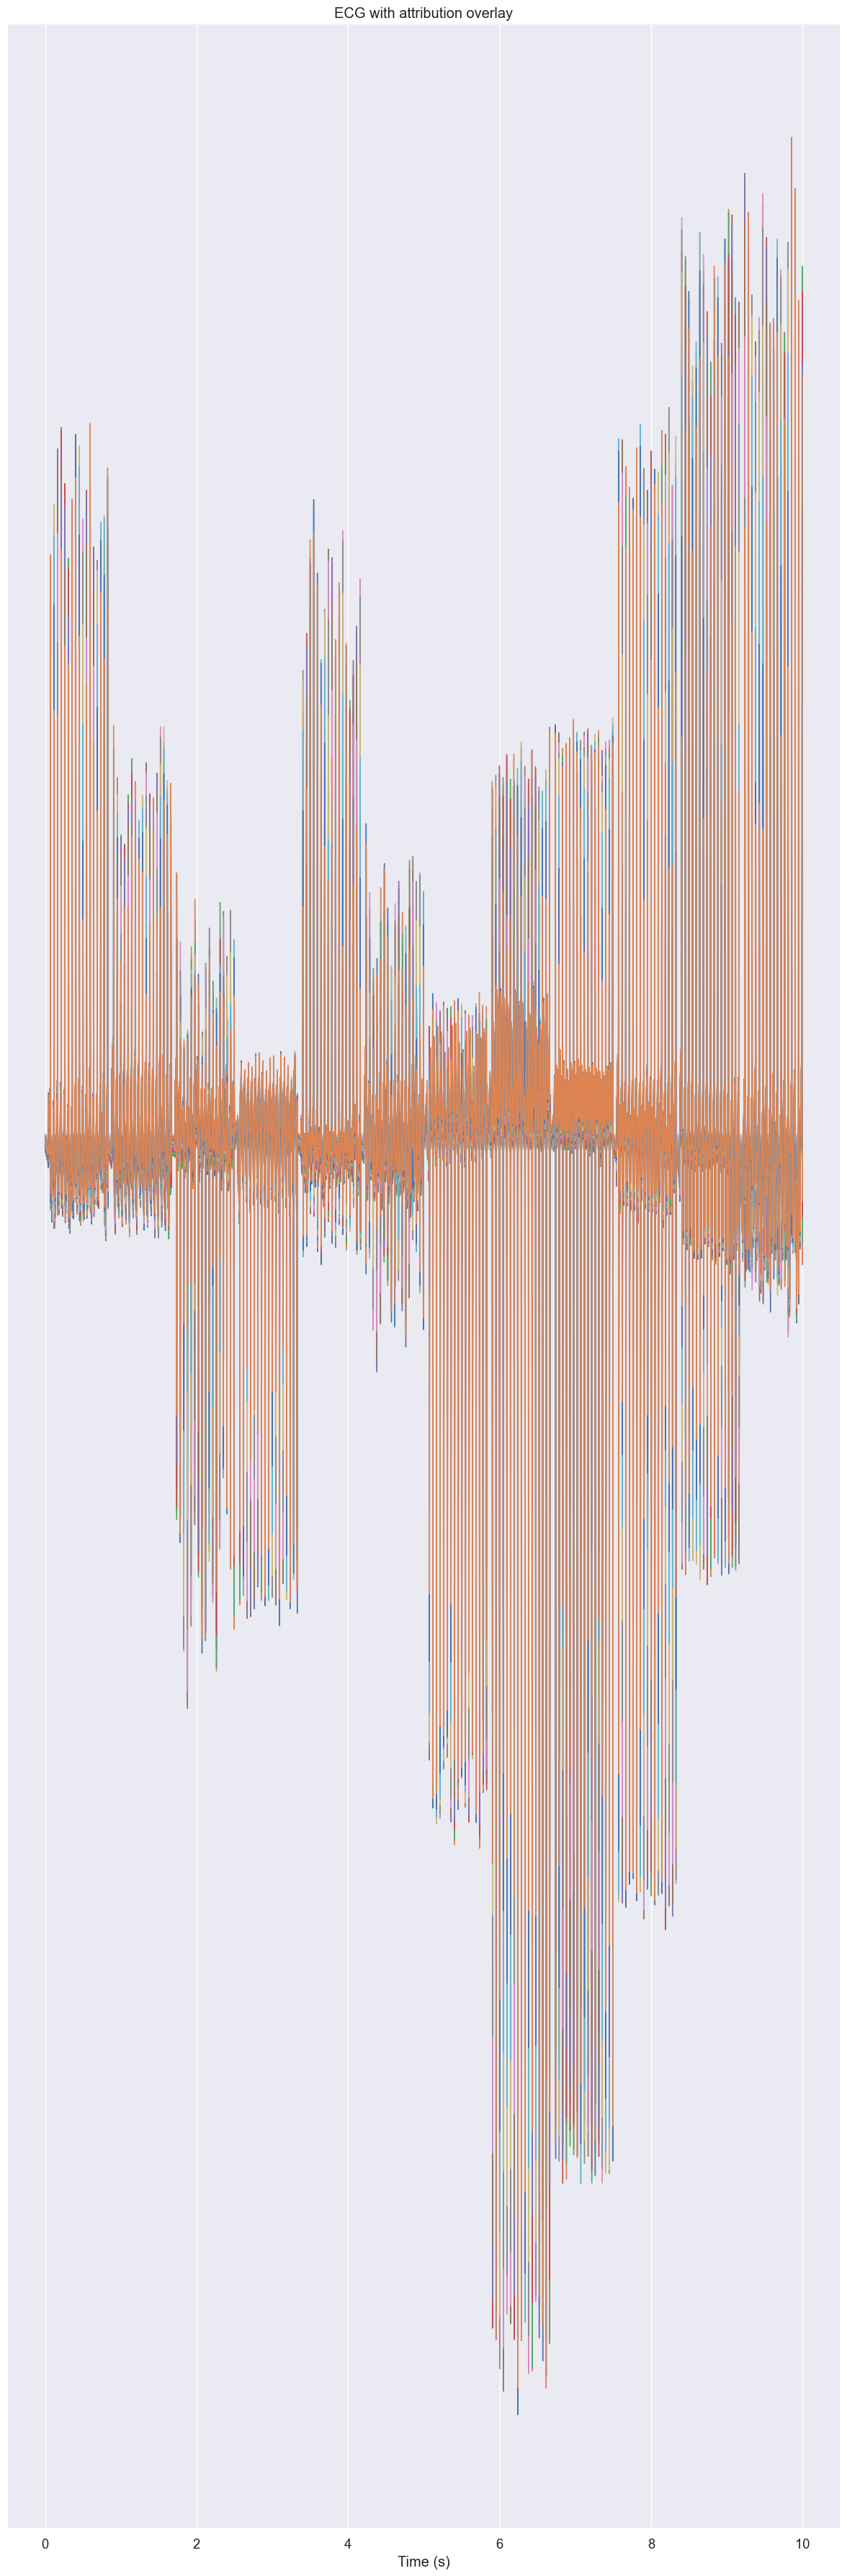

In [205]:
t = np.arange(ecg_single.shape[1]) / fs
plt.figure(figsize=(12, 3*ecg_single.shape[0]))

for li in range(ecg_single.shape[0]):
    offset = 2.5 * li
    plt.plot(t, ecg_single[li] + offset, linewidth=1.0)
    a = np.abs(attr_single[li])
    a = a / (a.max() + 1e-8)
    plt.fill_between(t, offset, ecg_single[li] + offset, alpha=0.25, where=a>0, interpolate=True)

plt.xlabel('Time (s)')
plt.yticks([])
plt.title('ECG with attribution overlay')
plt.tight_layout()
plt.show()


---

# 🔍 Explainability Add-on (SHAP + LIME Overlays)
This section appends per-timestep ECG overlays showing which parts of the signal push the prediction toward the **target class** (red) or away (blue).
If you already have `model`, `X` (shape `(N, T, L)` or `(N, T)`), and `CLASS_NAMES` defined above, this will use them automatically.
    

In [206]:
X = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0]

In [207]:
# --- Config (edit as needed) ---
TARGET_CLASS_NAME = globals().get('TARGET_CLASS_NAME', 'AF')
BACKGROUND_N = globals().get('BACKGROUND_N', 200)
SAMPLE_INDEX = globals().get('SAMPLE_INDEX', 0)
RANDOM_SEED = globals().get('RANDOM_SEED', 42)

In [208]:
# Try to detect existing objects
_have_model = 'model' in globals()
_have_X = 'X' in globals()
_have_classes = 'CLASS_NAMES' in globals()

if not _have_model or not _have_X:
    print("Note: Could not find `model` and/or `X` in this notebook's globals.")
    print("      Please ensure your trained Keras model is in `model` and your data in `X` (N,T,L).")
    raise SystemExit

# Normalize X to (N, T, L)
if X.ndim == 2:
    X = X[..., None]
N, T, L = X.shape

# Target class index
if _have_classes and isinstance(CLASS_NAMES, (list, tuple)) and TARGET_CLASS_NAME in CLASS_NAMES:
    target_idx = CLASS_NAMES.index(TARGET_CLASS_NAME)
else:
    print("Warning: CLASS_NAMES not found or TARGET_CLASS_NAME not in CLASS_NAMES; using class index 0.")
    target_idx = 0

# Pick sample
idx = int(SAMPLE_INDEX) % N
x_sample = X[idx:idx+1]  # (1,T,L)

def plot_ecg_overlay(time, signal, contrib, title="ECG with Overlay", lead_name=None, vmin=None, vmax=None):
    signal = np.asarray(signal).reshape(-1)
    contrib = np.asarray(contrib).reshape(-1)
    Tloc = len(signal)
    if time is None:
        time = np.arange(Tloc)
    if vmin is None or vmax is None:
        amax = np.nanmax(np.abs(contrib)) if np.nanmax(np.abs(contrib))>0 else 1.0
        vmin, vmax = -amax, amax

    points = np.array([time, signal]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)
    lc = LineCollection(segments, cmap='coolwarm', norm=norm)
    lc.set_array(contrib[:-1])
    lc.set_linewidth(1.5)

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.add_collection(lc)
    ax.set_xlim(time.min(), time.max())
    pad = 0.05*(signal.max()-signal.min() + 1e-8)
    ax.set_ylim(signal.min()-pad, signal.max()+pad)
    ax.set_title(title + (f" — Lead: {lead_name}" if lead_name else ""))
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("mV")
    cbar = plt.colorbar(lc, ax=ax)
    cbar.set_label("Contribution → target class (red = positive, blue = negative)")
    plt.show()

def summarize_top_segments(contrib, segment_len=40, top_k=10, min_gap=20):
    Tloc = len(contrib)
    scores = np.array([contrib[i:i+segment_len].sum() for i in range(0, max(1, Tloc-segment_len+1))])
    idxs = scores.argsort()[::-1]
    selected = []
    for i in idxs:
        s, e = i, i+segment_len
        if all((abs(s - ps) >= min_gap and abs(e - pe) >= min_gap) for ps, pe, _ in selected):
            selected.append((s, e, scores[i]))
            if len(selected) >= top_k:
                break
    return selected


shap_values shape: (1, 5000, 12, 27)
harmonized shap_arr: (27, 5000, 12) target_contrib: (5000, 12)


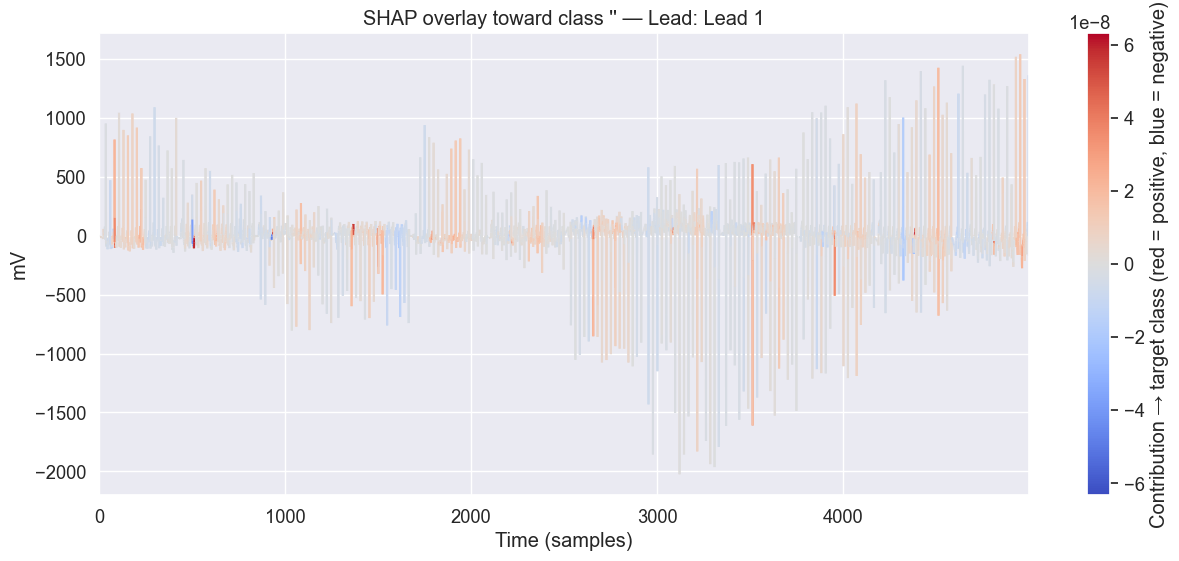

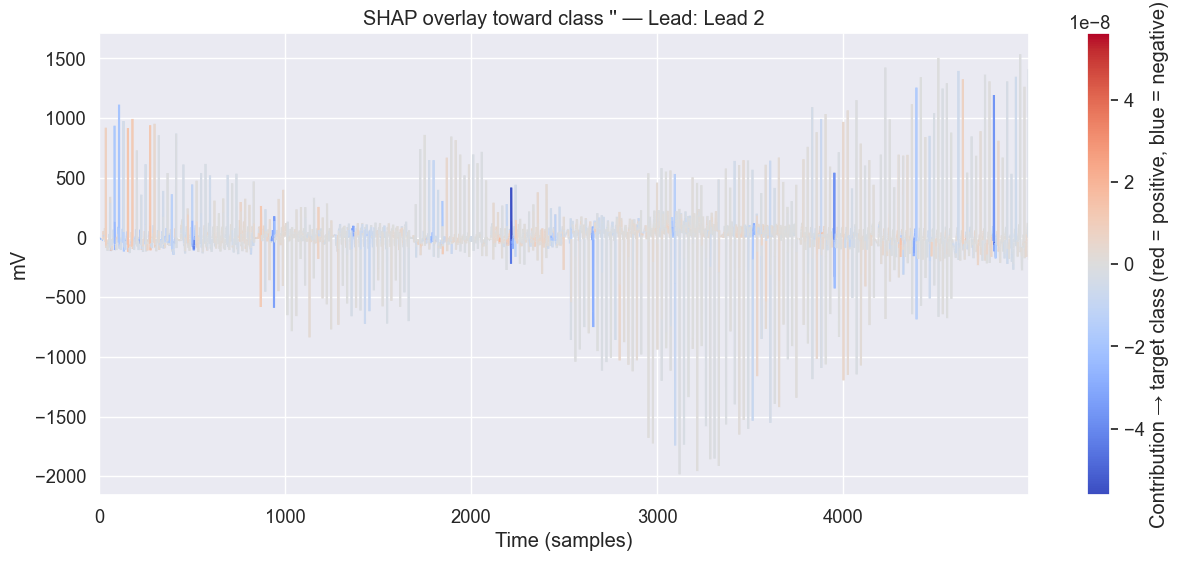

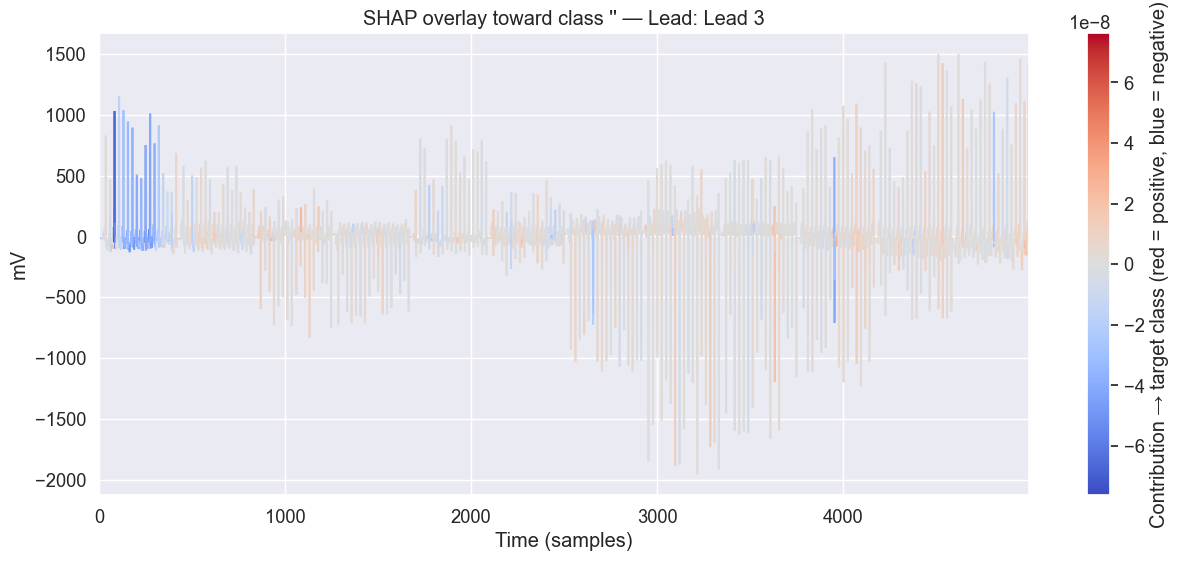

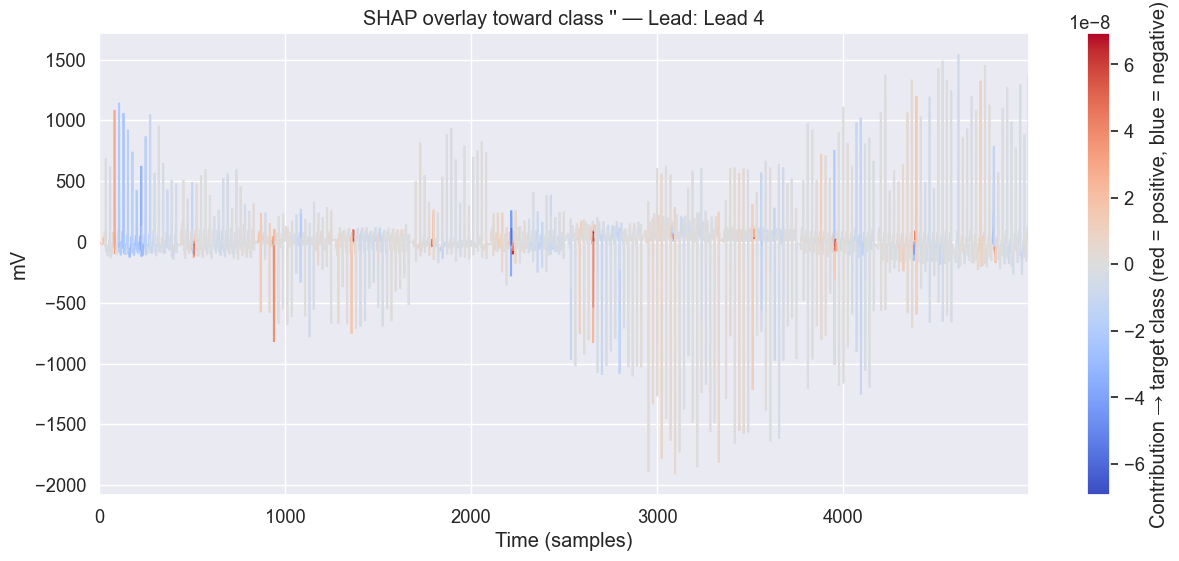

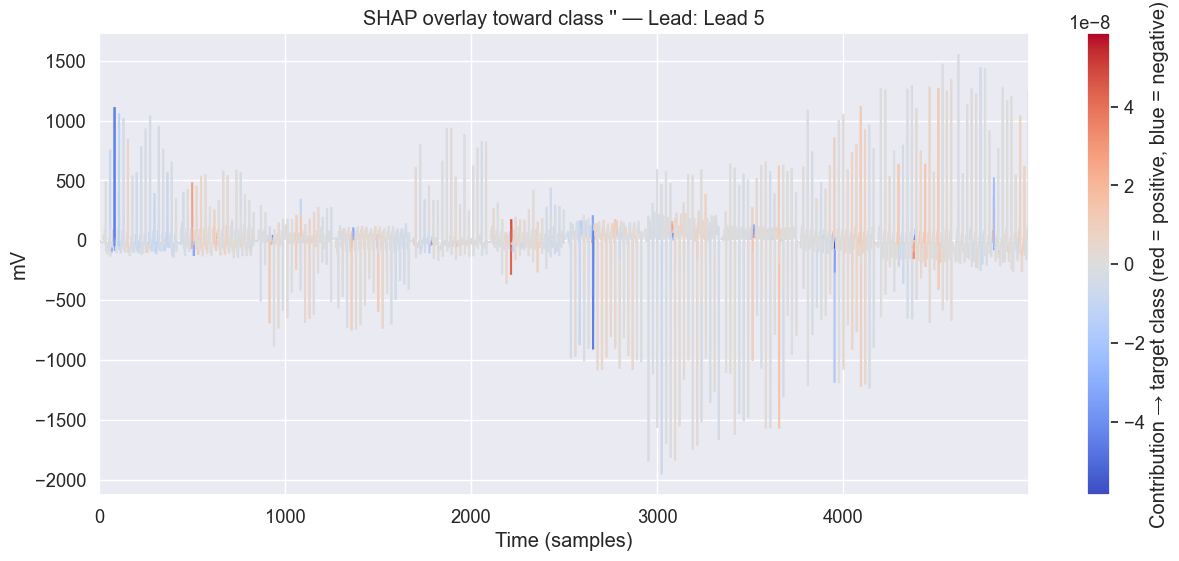

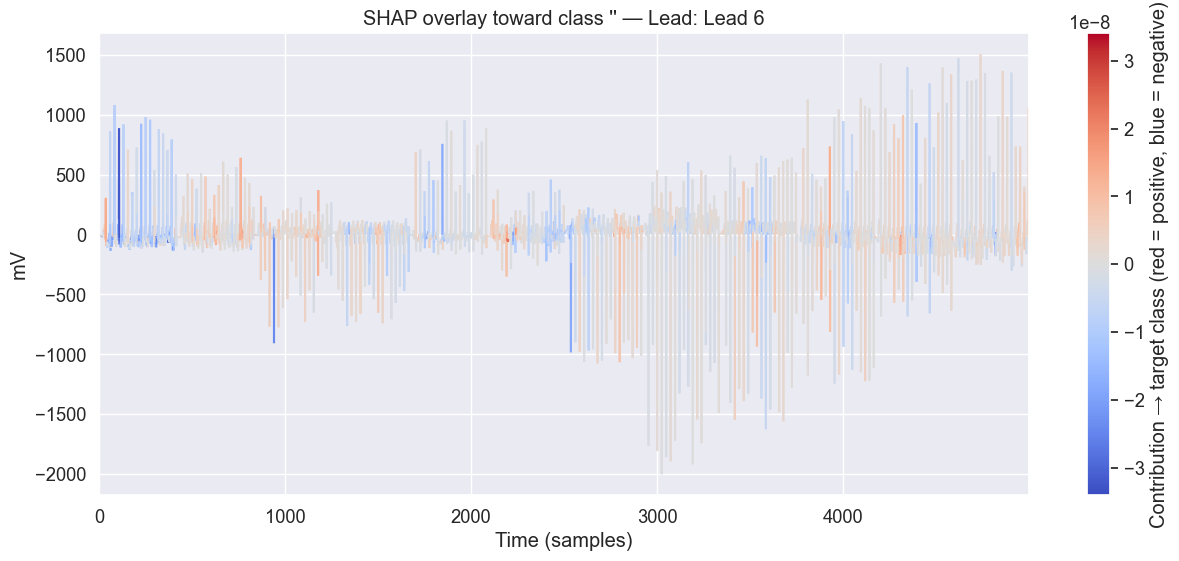

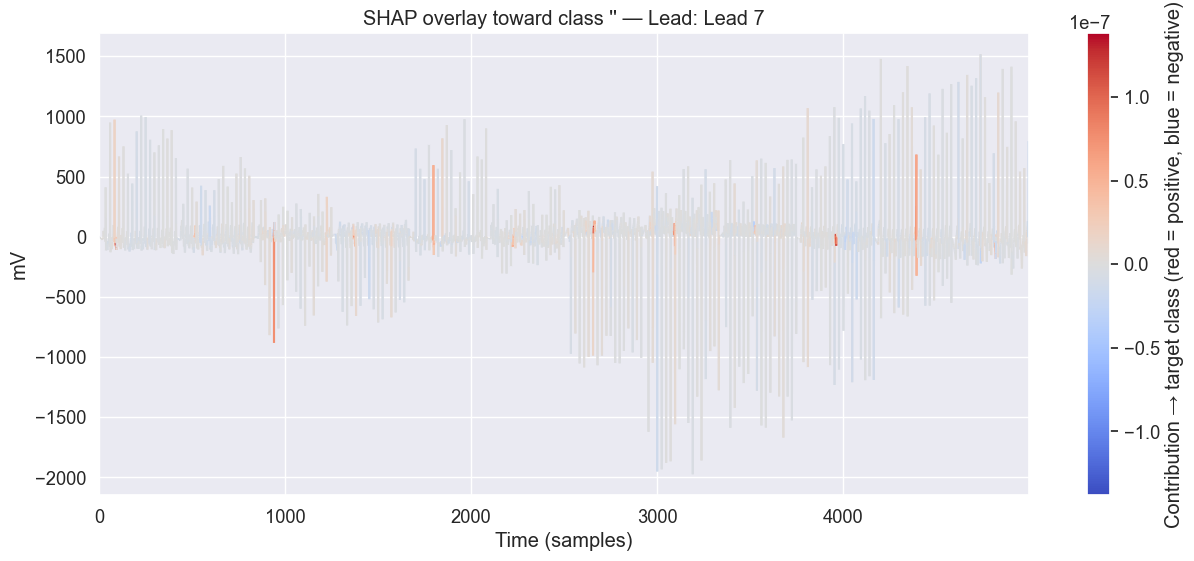

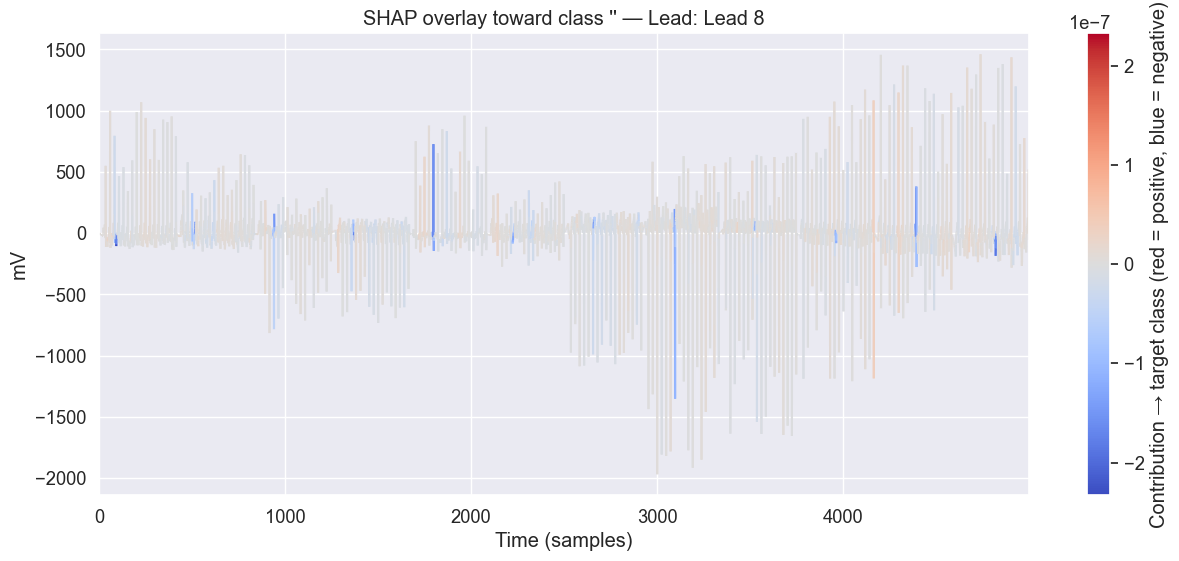

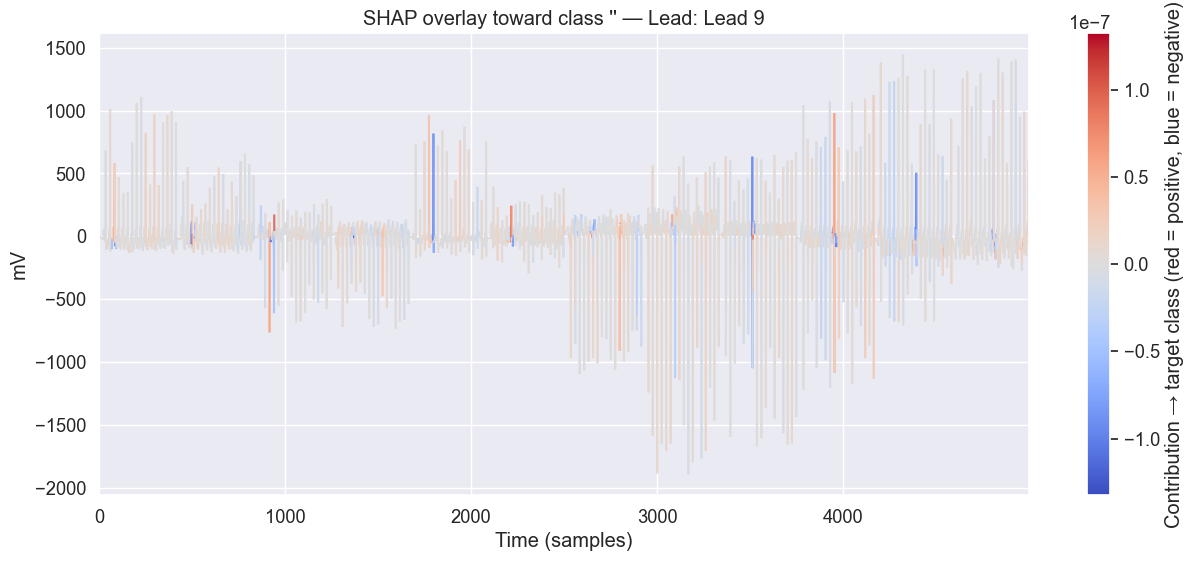

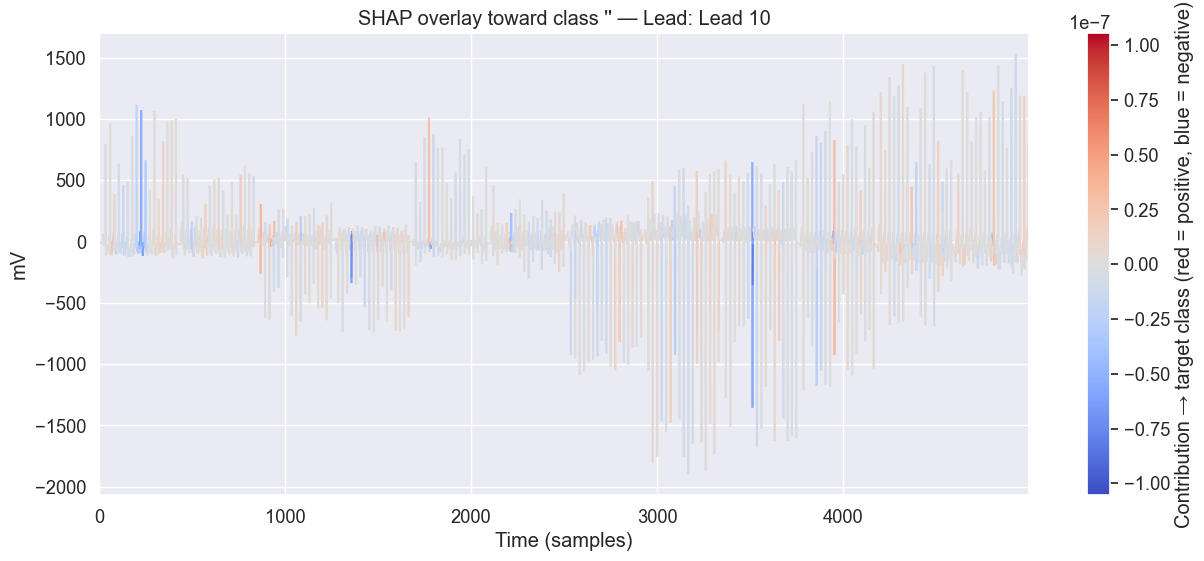

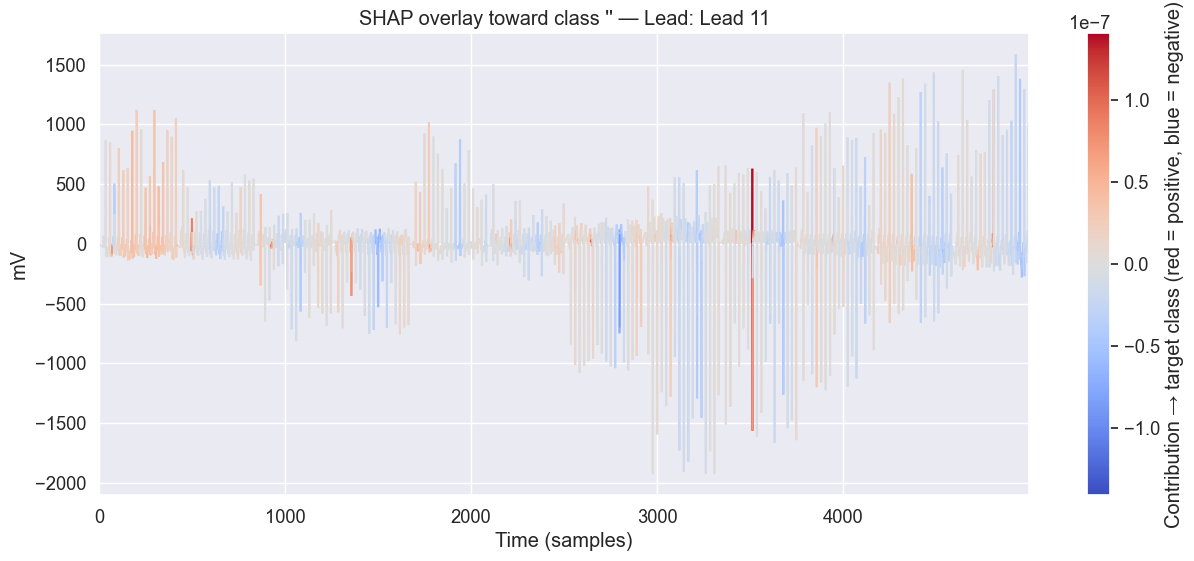

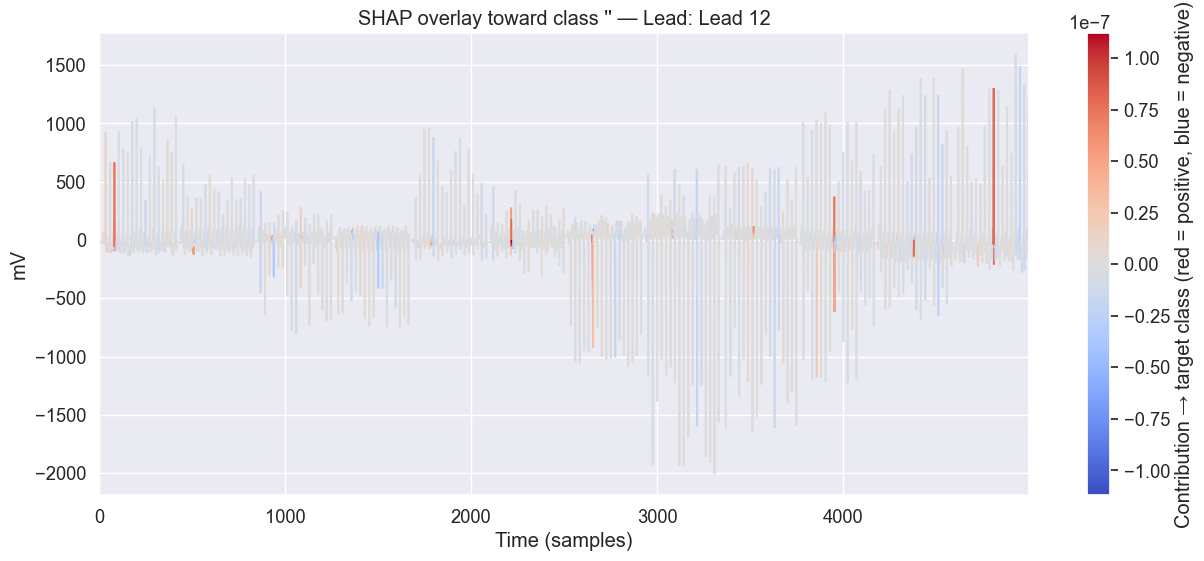

Top suspicious segments (mean across leads):
   2116– 2156  score=0.000
   4287– 4327  score=0.000
    840–  880  score=0.000
   2136– 2176  score=0.000
   4718– 4758  score=0.000
   1750– 1790  score=0.000
   3424– 3464  score=0.000
   1258– 1298  score=0.000
    896–  936  score=0.000
   2179– 2219  score=0.000


In [209]:
# Figure out num_classes from CLASS_NAMES or the model
if 'CLASS_NAMES' in globals() and isinstance(CLASS_NAMES, (list, tuple)):
    num_classes = len(CLASS_NAMES)
else:
    # best-effort fallback
    try:
        out_shape = getattr(model, 'output_shape', None)
        # Keras can return lists for multi-head; handle a few cases
        if isinstance(out_shape, (list, tuple)):
            if isinstance(out_shape, list):
                out_shape = out_shape[0]
            # out_shape like (None, C) or (None, T, L, C)
        num_classes = out_shape[-1] if out_shape is not None and isinstance(out_shape[-1], int) else None
    except Exception:
        num_classes = None

# --- Harmonize to (num_classes, T, L) ---
def to_class_T_L(shap_values, X, num_classes_hint=None):
    T, L = X.shape[1], X.shape[2]

    # Case A: list of arrays (one per class) -> stack
    if isinstance(shap_values, list):
        # Expect each sv either shaped like (n_samples, T, L) or (T, L)
        arrs = []
        for sv in shap_values:
            sv = np.asarray(sv)
            if sv.ndim == 3:      # (n_samples, T, L)
                arrs.append(sv[0])
            elif sv.ndim == 2:    # (T, L)
                arrs.append(sv)
            elif sv.ndim == 1 and sv.size == T*L:
                arrs.append(sv.reshape(T, L))
            else:
                raise ValueError(f"Unexpected per-class sv shape {sv.shape}")
        return np.stack(arrs, axis=0)  # (num_classes, T, L)

    # Case B: ndarray
    sv = np.asarray(shap_values)

    # Common: (n_samples, T, L, C)
    if sv.ndim == 4 and sv.shape[0] == 1 and (num_classes_hint is None or sv.shape[-1] == num_classes_hint):
        return np.moveaxis(sv[0], -1, 0)  # -> (C, T, L)

    # Sometimes: (n_samples, C, T, L)
    if sv.ndim == 4 and sv.shape[0] == 1 and (num_classes_hint is None or sv.shape[1] == num_classes_hint):
        return sv[0]  # already (C, T, L)

    # Single-output models: (n_samples, T, L)
    if sv.ndim == 3 and sv.shape[0] == 1:
        return sv.reshape(1, T, L)  # (1, T, L)

    # Flat vector per sample: (n_samples, T*L) or (T*L,)
    if sv.ndim == 2 and sv.shape[0] == 1 and sv.shape[1] == T*L:
        return sv.reshape(1, T, L)
    if sv.ndim == 1 and sv.size == T*L:
        return sv.reshape(1, T, L)

    raise ValueError(f"Don't know how to convert SHAP array with shape {sv.shape} to (classes, T, L).")

# Use the converter
shap_arr = to_class_T_L(shap_values, X, num_classes_hint=num_classes)
target_contrib = shap_arr[target_idx]  # (T, L)

print("shap_values shape:", np.asarray(shap_values).shape)
print("harmonized shap_arr:", shap_arr.shape, "target_contrib:", target_contrib.shape)


# Plot overlays per lead
for lead in range(L):
    plot_ecg_overlay(
        time=np.arange(T),
        signal=x_sample[0, :, lead],
        contrib=target_contrib[:, lead],
        title=f"SHAP overlay toward class '{TARGET_CLASS_NAME}'",
        lead_name=f"Lead {lead+1}"
    )

# Summarize strongest intervals
top_segments = summarize_top_segments(target_contrib.mean(axis=1))
print("Top suspicious segments (mean across leads):")
for (s, e, sc) in top_segments:
    print(f"  {s:5d}–{e:5d}  score={sc:.3f}")


LIME contrib shape: (5000,)


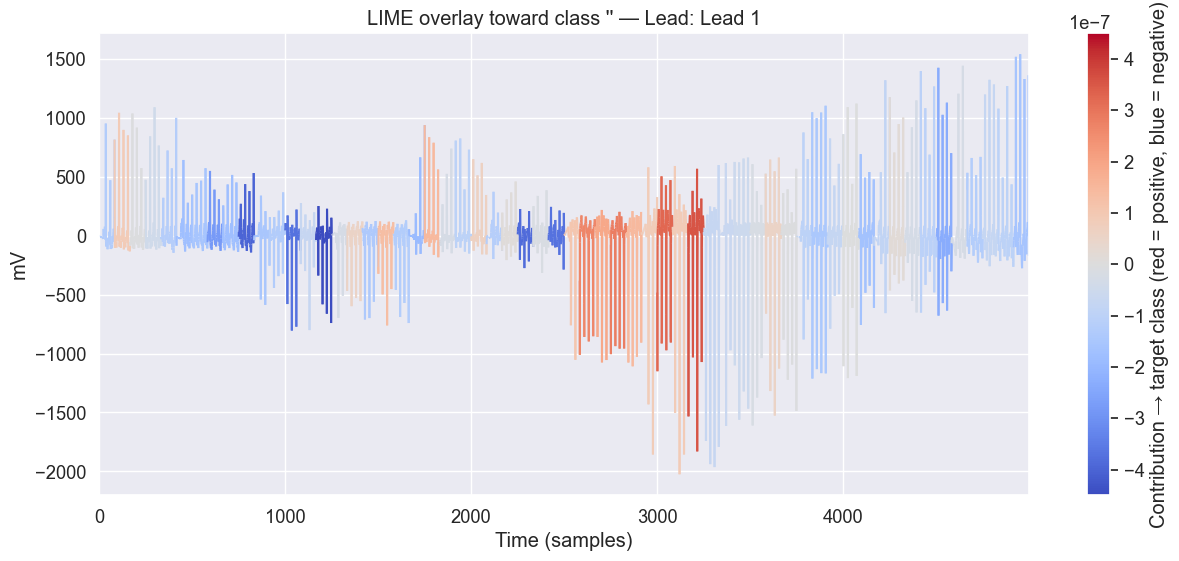

In [210]:
def segment_time_series(x, n_segments=50):
    Tloc = x.shape[0]
    bounds = np.linspace(0, Tloc, n_segments+1).astype(int)
    return [(bounds[i], bounds[i+1]) for i in range(n_segments)]

def lime_explain_timeseries(model, x, class_idx, n_segments=60, num_samples=1500, seed=RANDOM_SEED):
    Tloc, Lloc = x.shape
    segments = segment_time_series(x[:, 0], n_segments=n_segments)
    rng = check_random_state(seed)

    def data_generator(mask_vectors):
        M = mask_vectors.shape[0]
        X_masked = np.repeat(x[None, ...], M, axis=0)
        for m in range(M):
            for j, (s, e) in enumerate(segments):
                if mask_vectors[m, j] == 0:
                    X_masked[m, s:e, :] = 0.0
        return model.predict(X_masked, verbose=0)

    n_feat = len(segments)
    training_data = rng.randint(0, 2, size=(min(2048, max(512, n_segments*20)), n_feat))
    explainer = LimeTabularExplainer(
        training_data,
        feature_names=[f"{s}-{e}" for s, e in segments],
        class_names=CLASS_NAMES if 'CLASS_NAMES' in globals() else None,
        discretize_continuous=False,
        random_state=rng
    )

    def predict_fn(z):
        return data_generator(z.astype(int))

    z0 = np.ones((1, n_feat))
    exp = explainer.explain_instance(
        z0[0],
        predict_fn,
        labels=[class_idx],
        num_features=n_feat,
        num_samples=num_samples
    )

    weights = dict(exp.as_list(label=class_idx))
    contrib = np.zeros(Tloc, dtype=float)
    for j, (s, e) in enumerate(segments):
        w = weights.get(f"{s}-{e}", 0.0)
        contrib[s:e] += w / max(1, (e - s))
    return contrib, segments, exp

lime_contrib, lime_segments, lime_exp = lime_explain_timeseries(
    model, x_sample[0], class_idx=target_idx, n_segments=60, num_samples=1500
)
print("LIME contrib shape:", lime_contrib.shape)

lead_to_plot = 0

plot_ecg_overlay(
    time=np.arange(T),
    signal=x_sample[0, :, lead_to_plot],
    contrib=lime_contrib,
    title=f"LIME overlay toward class '{TARGET_CLASS_NAME}'",
    lead_name=f"Lead {lead_to_plot+1}"
)


In [211]:

def describe_findings(shap_contrib, lime_contrib, top_k=5):
    msg = []
    target_name = TARGET_CLASS_NAME if 'TARGET_CLASS_NAME' in globals() else str(target_idx)
    msg.append(f"Target class: {target_name}")
    lead_scores = shap_contrib.clip(min=0).sum(axis=0)
    top_leads = np.argsort(lead_scores)[::-1][:min(top_k, len(lead_scores))]
    msg.append("Top leads by positive SHAP contribution: " + ", ".join([f"Lead {i+1}" for i in top_leads]))

    comb = shap_contrib.mean(axis=1) + lime_contrib

    segs = summarize_top_segments(comb, segment_len=max(20, X.shape[1]//50), top_k=top_k)
    for rank, (s, e, sc) in enumerate(segs, 1):
        msg.append(f"{rank}. Suspicious interval {s}–{e} (mean+LIME score={sc:.2f})")
    return "\n".join(msg)

summary_text = describe_findings(target_contrib, lime_contrib)
print(summary_text)


Target class: 
Top leads by positive SHAP contribution: Lead 11, Lead 9, Lead 8, Lead 1, Lead 10
1. Suspicious interval 3150–3250 (mean+LIME score=0.00)
2. Suspicious interval 2988–3088 (mean+LIME score=0.00)
3. Suspicious interval 3170–3270 (mean+LIME score=0.00)
4. Suspicious interval 2733–2833 (mean+LIME score=0.00)
5. Suspicious interval 3008–3108 (mean+LIME score=0.00)
